
# 🤖 AI Chatbot Conversations — Full Data Analysis

This notebook performs a comprehensive analysis on **12,448 conversations** collected from an AI chatbot system between **October 2024 and March 2026**, spanning **80 detected languages**.

### What This Notebook Covers

| # | Topic | What It Answers |
|---|-------|-----------------|
| 1 | Temporal Analysis | *When* do users talk to the bot? (Year, month, day, hour) |
| 2 | Engagement Analysis | *How deeply* do users interact? Do they leave without talking? |
| 3 | Language Analysis | *What languages* do users speak? Which are most engaged? |
| 4 | Bot Failure Analysis | *When* did the bot fail to respond? Why? |
| 5 | Conversation Balance | *Who talks more* — the bot or the user? |
| 6 | Peak Times by Language | *When* is each language community most active? |
| 7 | Response Time Analysis | *How fast* does the bot reply? How fast do users reply? |
| 8 | Session & Gap Analysis | Do users *come back* to conversations? |
| 9 | Language Confidence | How *reliable* is the language detection? |
| 10 | AI Performance Dashboard | Overall *speed benchmarks* by language, hour, and conversation length |

### Important Notes
- **Outlier handling**: Some data contains extreme values (e.g., AI response time of 24 days). Where applicable, the analysis shows both raw and cleaned statistics (top 1% outliers removed).
- **Month accumulation bias**: Some months (like March) appear in multiple years. The analysis flags this and provides a separate timeline chart without accumulation.

---


## ⚙️ Cell 0: Setup & Data Loading

This cell handles the initial setup:
- Imports all required libraries (`pandas`, `matplotlib`, `seaborn`, `numpy`)
- Loads the CSV file into a DataFrame
- Converts time columns (`start_time`, `end_time`) to proper datetime format
- Calculates `duration_minutes` from the time difference
- Extracts `year` and `month_name` from `start_time`
- Maps existing columns (`start_hour` → `hour`, `day_of_week` → `day_name`) for internal consistency
- Fills any missing values in message count columns with 0

After running this cell, you should see a confirmation message with the total number of conversations, date range, and column list.

In [1]:
# =============================================================================
# COMPLETE CHATBOT CONVERSATION ANALYSIS
# =============================================================================
# This script performs 10 analyses on chatbot conversation data.
# Topics 1-6: Adapted from previous code
# Topics 7-10: New analyses for new columns
# =============================================================================

# ======================= CELL 0: SETUP & DATA LOADING ========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# --- Load Data ---
df = pd.read_csv('/content/drive/MyDrive/Islam Chat Conversations/New task conversation analysis (April)/Original Data after preparation/organized_conversations_with_language.csv')  # <-- UPDATE THIS PATH to your actual file


# --- Convert time columns ---
df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')

# --- Calculate duration in minutes from timestamps ---
df['duration_minutes'] = (df['end_time'] - df['start_time']).dt.total_seconds() / 60

# --- Extract year and month_name from start_time (needed for temporal analysis) ---
df['year'] = df['start_time'].dt.year
df['month_name'] = df['start_time'].dt.month_name()

# --- Use pre-built columns directly (rename for internal consistency) ---
# 'start_hour' and 'day_of_week' already exist in the new data
# We map them to 'hour' and 'day_name' for code compatibility
df['hour'] = df['start_hour']
df['day_name'] = df['day_of_week']

# --- Fill missing numerical values ---
df['user_msg_count'] = df['user_msg_count'].fillna(0)
df['bot_msg_count'] = df['bot_msg_count'].fillna(0)
df['total_messages'] = df['total_messages'].fillna(0)

# --- Global constants ---
total_convs = len(df)

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

print("=" * 60)
print("DATA LOADED SUCCESSFULLY")
print("=" * 60)
print(f"  Total Conversations: {total_convs}")
print(f"  Date Range: {df['start_time'].min().date()} to {df['start_time'].max().date()}")
print(f"  Columns ({len(df.columns)}): {df.columns.tolist()}")
print(f"  Languages Found: {df['conversation_language'].nunique()}")
print("=" * 60)

DATA LOADED SUCCESSFULLY
  Total Conversations: 12448
  Date Range: 2024-10-17 to 2026-03-26
  Columns (23): ['general_chat_id', 'total_messages', 'user_msg_count', 'bot_msg_count', 'start_time', 'end_time', 'conversation_duration', 'avg_response_time_user_sec', 'avg_response_time_ai_sec', 'max_gap_sec', 'num_sessions', 'start_hour', 'day_of_week', 'full_conversation', 'all_user_messages', 'all_bot_messages', 'conversation_language', 'language_confidence_score', 'duration_minutes', 'year', 'month_name', 'hour', 'day_name']
  Languages Found: 80


---

# 📊 Topic 1: Temporal Analysis — When Do Users Talk to the Bot?

**Goal**: Understand traffic patterns — which years, months, days, and hours see the most activity. This helps with resource planning and scheduling maintenance.

**Columns used**: `start_time` (to extract year and month), `start_hour`, `day_of_week`, `end_time` (to calculate duration)

This topic has 4 cells:

| Cell | What It Does |
|------|-------------|
| 1.1 | Yearly & monthly volume — text report + 2 bar charts |
| 1.1B | Year-month timeline — shows actual month-by-month trend without accumulation bias |
| 1.2 | Daily volume timeline — line chart with 7-day rolling average |
| 1.3 | Day × Hour heatmap — shows which day+hour combinations are busiest |
| 1.4 | Duration distribution — bucket table + two histograms (0-60 min and zoomed 0-10 min) |



📊 TOPIC 1: TEMPORAL ANALYSIS REPORT (Volume Trends)
  Total Conversations Analyzed: 12448
  Data Range: 2024-10-17 to 2026-03-26
  Peak Activity Day: Thursday
  Peak Activity Hour: 14:00
------------------------------------------------------------
  Peak Year:  2025 (11056 conversations)
  Peak Month: March (accumulated across all years)
------------------------------------------------------------

📈 Breakdown by Year:
    2024: 179 conversations
    2025: 11056 conversations
    2026: 1213 conversations

🗓️  Breakdown by Month (Seasonality):
    January: 736
    February: 659
    March: 3458
    April: 671
    May: 451
    June: 1790
    July: 791
    August: 514
    September: 516
    October: 1301
    November: 807
    December: 754

  ⚠️  Note: The following months appear in multiple years,
     so their accumulated totals may appear inflated:
       January: appears in 2 different years
       February: appears in 2 different years
       March: appears in 2 different years
    

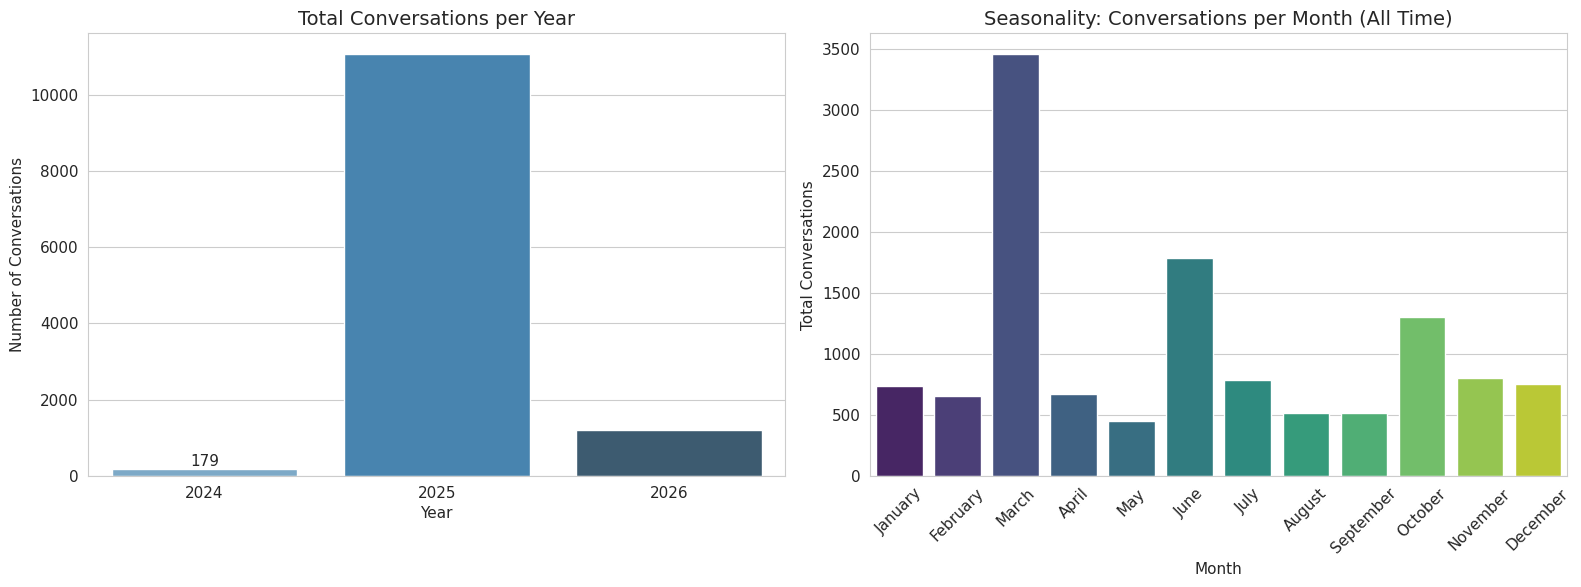

In [2]:
# =============================================================================
# TOPIC 1: TEMPORAL ANALYSIS (Time & Duration)
# =============================================================================

# ---------------------- TOPIC 1 - CELL 1: Yearly & Monthly Volume ------------

yearly_counts = df['year'].value_counts().sort_index()
monthly_counts = df['month_name'].value_counts().reindex(month_order).fillna(0)

busiest_day = df['day_name'].mode()[0]
busiest_hour = df['hour'].mode()[0]
busiest_year = yearly_counts.idxmax()
busiest_month = monthly_counts.idxmax()

print("\n")
print("📊 TOPIC 1: TEMPORAL ANALYSIS REPORT (Volume Trends)")
print("=" * 60)
print(f"  Total Conversations Analyzed: {total_convs}")
print(f"  Data Range: {df['start_time'].min().date()} to {df['start_time'].max().date()}")
print(f"  Peak Activity Day: {busiest_day}")
print(f"  Peak Activity Hour: {busiest_hour}:00")
print("-" * 60)
print(f"  Peak Year:  {busiest_year} ({yearly_counts.max()} conversations)")
print(f"  Peak Month: {busiest_month} (accumulated across all years)")
print("-" * 60)

print("\n📈 Breakdown by Year:")
for year, count in yearly_counts.items():
    print(f"    {year}: {count} conversations")

print("\n🗓️  Breakdown by Month (Seasonality):")
for month, count in monthly_counts.items():
    if count > 0:
        print(f"    {month}: {int(count)}")

month_year_counts = df.groupby('month_name')['year'].nunique().reindex(month_order).fillna(0)
multi_year_months = month_year_counts[month_year_counts > 1]
if len(multi_year_months) > 0:
    print("\n  ⚠️  Note: The following months appear in multiple years,")
    print("     so their accumulated totals may appear inflated:")
    for m, yrs in multi_year_months.items():
        print(f"       {m}: appears in {int(yrs)} different years")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=yearly_counts.index.astype(str), y=yearly_counts.values, ax=axes[0],
            palette='Blues_d', hue=yearly_counts.index.astype(str), legend=False)
axes[0].set_title('Total Conversations per Year', fontsize=14)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Conversations')
axes[0].bar_label(axes[0].containers[0])

active_months = monthly_counts[monthly_counts > 0]
sns.barplot(x=active_months.index, y=active_months.values, ax=axes[1],
            palette='viridis', hue=active_months.index, legend=False)
axes[1].set_title('Seasonality: Conversations per Month (All Time)', fontsize=14)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Conversations')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('topic1_cell1_yearly_monthly.png', dpi=150, bbox_inches='tight')
plt.show()


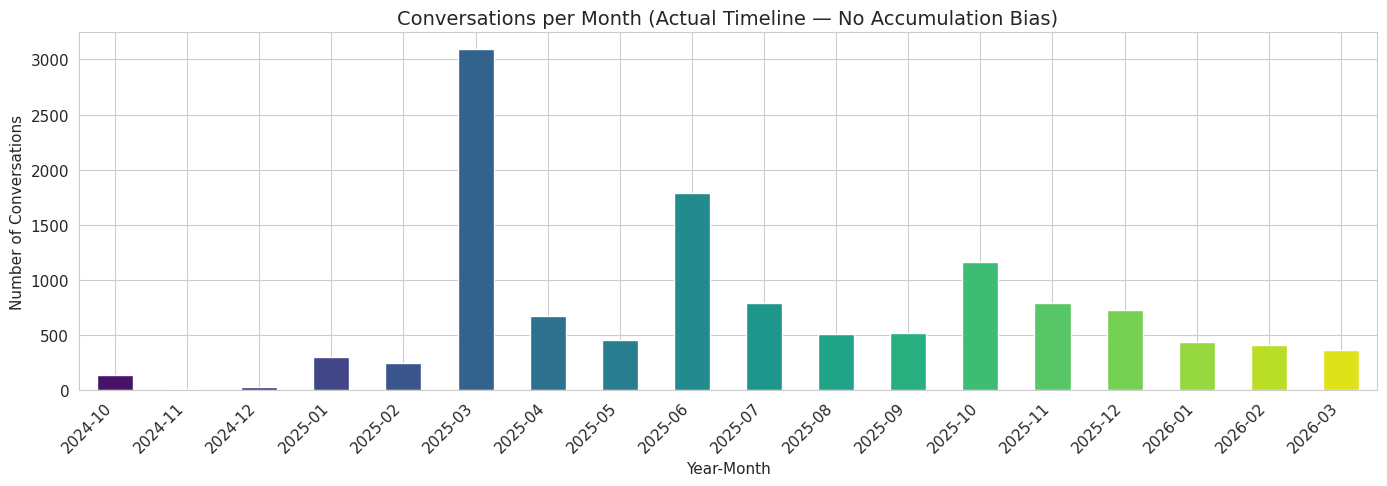

In [3]:


# ---------------------- TOPIC 1 - CELL 1B: Year-Month Timeline ---------------

df['year_month'] = df['start_time'].dt.to_period('M')
ym_counts = df['year_month'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
ax = ym_counts.plot(kind='bar', color=sns.color_palette('viridis', len(ym_counts)), edgecolor='white')
plt.title('Conversations per Month (Actual Timeline — No Accumulation Bias)', fontsize=14)
plt.xlabel('Year-Month')
plt.ylabel('Number of Conversations')

tick_positions = range(0, len(ym_counts), max(1, len(ym_counts) // 15))
ax.set_xticks(list(tick_positions))
ax.set_xticklabels([str(ym_counts.index[i]) for i in tick_positions], rotation=45, ha='right')

plt.tight_layout()
plt.savefig('topic1_cell1b_year_month_timeline.png', dpi=150, bbox_inches='tight')
plt.show()



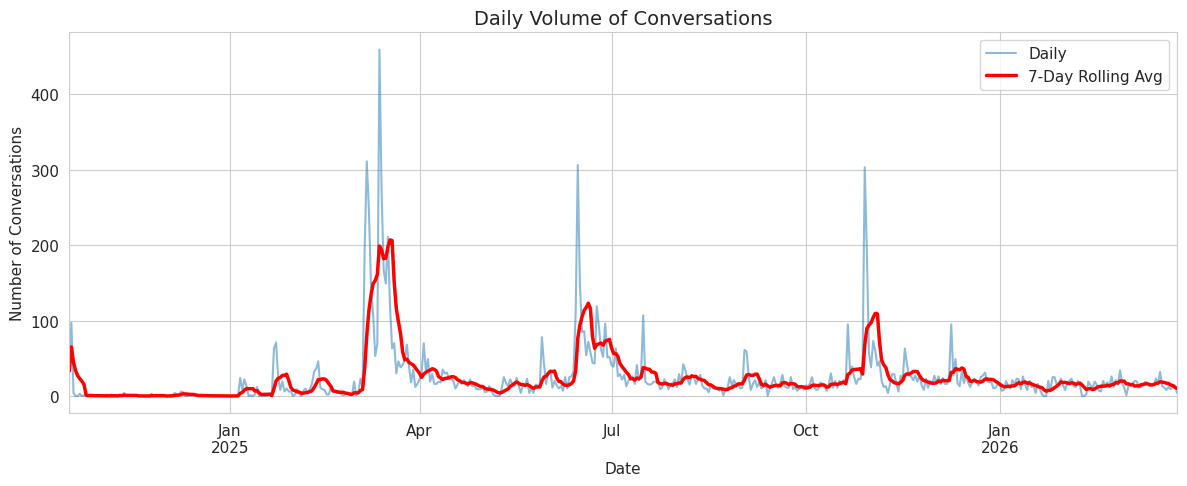

In [4]:

# ---------------------- TOPIC 1 - CELL 2: Daily Volume Timeline --------------

daily_counts = df.set_index('start_time').resample('D').size()

plt.figure(figsize=(12, 5))
daily_counts.plot(kind='line', color='#1f77b4', linewidth=1.5, alpha=0.5, label='Daily')
rolling_avg = daily_counts.rolling(7, min_periods=1).mean()
rolling_avg.plot(kind='line', color='red', linewidth=2.5, label='7-Day Rolling Avg')
plt.title('Daily Volume of Conversations', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of Conversations')
plt.legend()
plt.tight_layout()
plt.savefig('topic1_cell2_daily_volume.png', dpi=150, bbox_inches='tight')
plt.show()


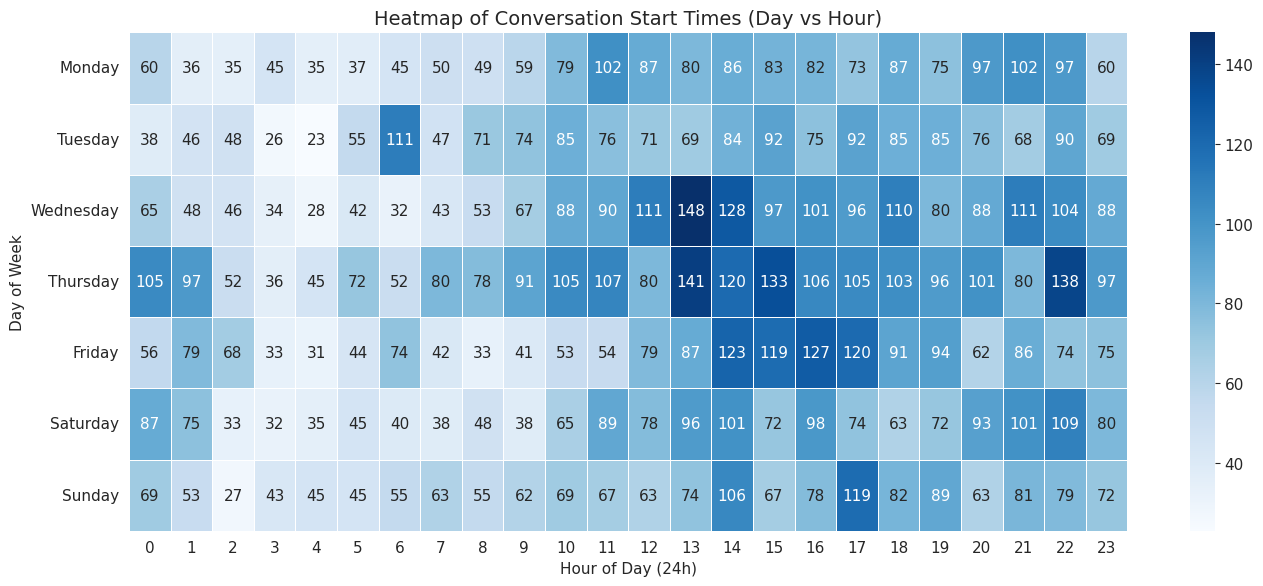

In [5]:

# ---------------------- TOPIC 1 - CELL 3: Heatmap (Day x Hour) ---------------

heatmap_data = df.groupby(['day_name', 'hour']).size().unstack(fill_value=0).reindex(day_order)
for h in range(24):
    if h not in heatmap_data.columns:
        heatmap_data[h] = 0
heatmap_data = heatmap_data[sorted(heatmap_data.columns)]

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='Blues', linewidths=0.5, annot=True, fmt='g')
plt.title('Heatmap of Conversation Start Times (Day vs Hour)', fontsize=14)
plt.ylabel('Day of Week')
plt.xlabel('Hour of Day (24h)')
plt.tight_layout()
plt.savefig('topic1_cell3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()



⏳ DURATION DISTRIBUTION TABLE
Duration Category         | Count      | Percentage
------------------------------------------------------------
Quick (< 10 mins)         | 10623      |  85.3%  █████████████████
Session (10-60 mins)      | 1128       |   9.1%  █
Hours (1-24 hrs)          | 447        |   3.6%  
Multi-Day (> 1 Day)       | 250        |   2.0%  

  Conversations under 60 minutes: 11751 out of 12448
  Conversations under 10 minutes: 10623 out of 12448


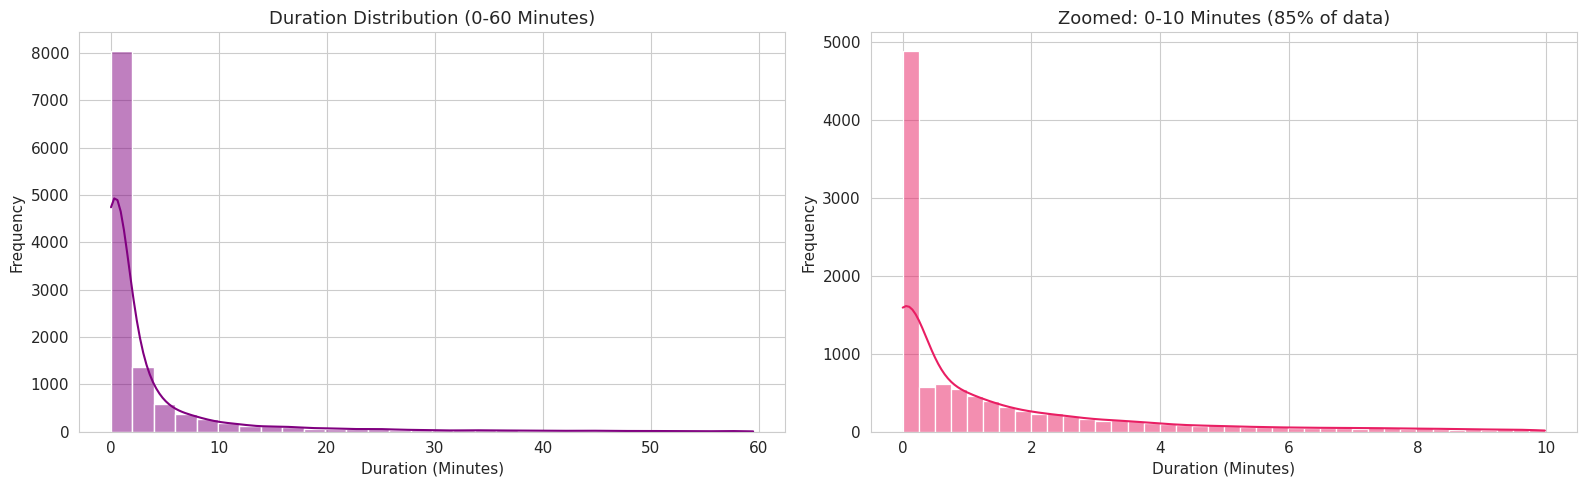

In [6]:

# ---------------------- TOPIC 1 - CELL 4: Duration Distribution ---------------

bins = [-1, 10, 60, 1440, float('inf')]
labels_dur = ['Quick (< 10 mins)', 'Session (10-60 mins)', 'Hours (1-24 hrs)', 'Multi-Day (> 1 Day)']
df['duration_bucket'] = pd.cut(df['duration_minutes'], bins=bins, labels=labels_dur)

bucket_counts = df['duration_bucket'].value_counts().sort_index()

print("\n⏳ DURATION DISTRIBUTION TABLE")
print("=" * 60)
print(f"{'Duration Category':<25} | {'Count':<10} | {'Percentage':<10}")
print("-" * 60)
for category, count in bucket_counts.items():
    pct = (count / total_convs) * 100
    bar = "█" * int(pct / 5)
    print(f"{category:<25} | {count:<10} | {pct:>5.1f}%  {bar}")
print("=" * 60)

short_chats = df[df['duration_minutes'] <= 60]
very_short = df[df['duration_minutes'] <= 10]
print(f"\n  Conversations under 60 minutes: {len(short_chats)} out of {total_convs}")
print(f"  Conversations under 10 minutes: {len(very_short)} out of {total_convs}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if len(short_chats) > 0:
    sns.histplot(short_chats['duration_minutes'], bins=30, kde=True, color='purple', ax=axes[0])
    axes[0].set_title('Duration Distribution (0-60 Minutes)', fontsize=13)
    axes[0].set_xlabel('Duration (Minutes)')
    axes[0].set_ylabel('Frequency')

if len(very_short) > 0:
    sns.histplot(very_short['duration_minutes'], bins=40, kde=True, color='#E91E63', ax=axes[1])
    axes[1].set_title(f'Zoomed: 0-10 Minutes ({len(very_short)/total_convs:.0%} of data)', fontsize=13)
    axes[1].set_xlabel('Duration (Minutes)')
    axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('topic1_cell4_duration.png', dpi=150, bbox_inches='tight')
plt.show()

### 📝 Topic 1 — Key Takeaways

- **Massive growth**: From 179 conversations in Q4 2024 to 11,056 in 2025 — the system went from testing to mainstream adoption.
- **Peak activity**: Thursday at 2:00 PM — consistent with working hours in the Middle East and East Africa.
- **Seasonal dip**: Summer months (July–September) show lower activity, possibly reflecting user behavior patterns.
- **Month inflation warning**: March appears as the busiest month (3,458), but this is because it includes data from both 2025 and 2026. The year-month timeline chart (Cell 1.1B) provides the accurate picture.
- **85% of conversations are under 10 minutes**: Most users come with a specific question and leave quickly. The zoomed histogram reveals the detailed shape of this majority.
- **Multi-day conversations (2%)**: These 250 conversations represent users who return over several days — likely complex or ongoing topics.

---

# 📊 Topic 2: Engagement Analysis — Do Users Actually Interact?

**Goal**: Measure whether users actively participate in conversations or simply open the chat and leave. This is measured using the **Bounce Rate** — the percentage of users who opened a conversation but never sent a message.

**Columns used**: `user_msg_count`

This topic has 2 cells:

| Cell | What It Does |
|------|-------------|
| 2.1 | Engagement report — bounce rate, engagement rate, depth breakdown (text) |
| 2.2 | Visualizations — pie chart (bounce vs engaged) + horizontal bar chart (depth categories) |

In [7]:

# =============================================================================
# TOPIC 2: ENGAGEMENT ANALYSIS (Interaction Quality)
# =============================================================================

# ---------------------- TOPIC 2 - CELL 1: Engagement Report ------------------

# Calculate bounce rates
bounce_count = df[df['user_msg_count'] == 0].shape[0]
engaged_count = df[df['user_msg_count'] > 0].shape[0]
bounce_rate = (bounce_count / total_convs) * 100

# Categorize conversation depth
def categorize_depth(msg_count):
    if msg_count == 0: return '0: No Reply'
    elif msg_count <= 2: return '1: Short (1-2 Msgs)'
    elif msg_count <= 10: return '2: Medium (3-10 Msgs)'
    else: return '3: Long (10+ Msgs)'

df['engagement_category'] = df['user_msg_count'].apply(categorize_depth)
category_counts = df['engagement_category'].value_counts().sort_index()

print("\n")
print("📊 TOPIC 2: ENGAGEMENT ANALYSIS REPORT")
print("=" * 60)
print(f"  Bounce Rate (No User Reply): {bounce_rate:.1f}% ({bounce_count} chats)")
print(f"  Engagement Rate (Active):    {100 - bounce_rate:.1f}% ({engaged_count} chats)")
print("-" * 60)
print("  Breakdown by Conversation Depth:")
for category, count in category_counts.items():
    print(f"    {category}: {count} ({count/total_convs:.1%})")
print("=" * 60)




📊 TOPIC 2: ENGAGEMENT ANALYSIS REPORT
  Bounce Rate (No User Reply): 0.8% (100 chats)
  Engagement Rate (Active):    99.2% (12348 chats)
------------------------------------------------------------
  Breakdown by Conversation Depth:
    0: No Reply: 100 (0.8%)
    1: Short (1-2 Msgs): 7514 (60.4%)
    2: Medium (3-10 Msgs): 4285 (34.4%)
    3: Long (10+ Msgs): 549 (4.4%)


### 📝 Topic 2 — Key Takeaways

- **Bounce rate is just 0.8%** — only 100 out of 12,448 users opened the chat without sending any message. This is excellent — it means the chatbot is meeting a genuine need.
- **60.4% are short conversations** (1–2 user messages): The dominant pattern is ask-one-question-get-answer-leave.
- **34.4% are medium** (3–10 messages): Users asking follow-up questions.
- **4.4% are long** (10+ messages): Extended, detailed discussions — these represent the most complex use cases.

---

# 🌍 Topic 3: Language Analysis — What Languages Do Users Speak?

**Goal**: Identify the most-used languages, their distribution, and whether engagement varies by language. This helps prioritize which languages need better bot performance.

**Columns used**: `conversation_language`, `user_msg_count`

This topic has 3 cells:

| Cell | What It Does |
|------|-------------|
| 3.1 | Full language distribution table + average messages per language (text) |
| 3.2 | Language distribution chart — pie chart (≤8 languages) or horizontal bar (>8 languages) |
| 3.3 | Average user messages per language — bar chart comparing top languages |

In [9]:

# =============================================================================
# TOPIC 3: LANGUAGE ANALYSIS
# =============================================================================

# ---------------------- TOPIC 3 - CELL 1: Language Report --------------------

# Clean language column
df['conversation_language'] = df['conversation_language'].fillna('Unknown')
df['conversation_language'] = df['conversation_language'].apply(
    lambda x: x.strip().title() if isinstance(x, str) else str(x)
)

# Calculate counts
lang_counts = df['conversation_language'].value_counts()
top_lang_counts = lang_counts.head(10)
top_lang_list = top_lang_counts.index.tolist()

# Average messages per language (top languages)
df_top_lang = df[df['conversation_language'].isin(top_lang_list)]
avg_msgs_per_lang = df_top_lang.groupby('conversation_language')['user_msg_count'].mean().sort_values(ascending=False)

print("\n")
print("📊 TOPIC 3: LANGUAGE ANALYSIS REPORT")
print("=" * 60)
print(f"{'Language':<30} | {'Conversations':<15} | {'Percentage':<10}")
print("-" * 60)
for lang, count in lang_counts.items():
    pct = (count / total_convs) * 100
    print(f"{lang:<30} | {count:<15} | {pct:.2f}%")
print("-" * 60)
print("\n  User Engagement (Avg Msgs) by Language:")
for lang, avg in avg_msgs_per_lang.items():
    print(f"    {lang}: {avg:.1f} messages per chat")
print("=" * 60)





📊 TOPIC 3: LANGUAGE ANALYSIS REPORT
Language                       | Conversations   | Percentage
------------------------------------------------------------
Arabic                         | 5667            | 45.53%
English                        | 4293            | 34.49%
Swahili                        | 579             | 4.65%
Japanese                       | 350             | 2.81%
French                         | 302             | 2.43%
Filipino                       | 189             | 1.52%
Central Kurdish                | 165             | 1.33%
Korean                         | 117             | 0.94%
Spanish                        | 113             | 0.91%
Urdu                           | 83              | 0.67%
Najdi Arabic                   | 69              | 0.55%
Chinese                        | 55              | 0.44%
German                         | 51              | 0.41%
Portuguese                     | 42              | 0.34%
Turkish                        | 35    

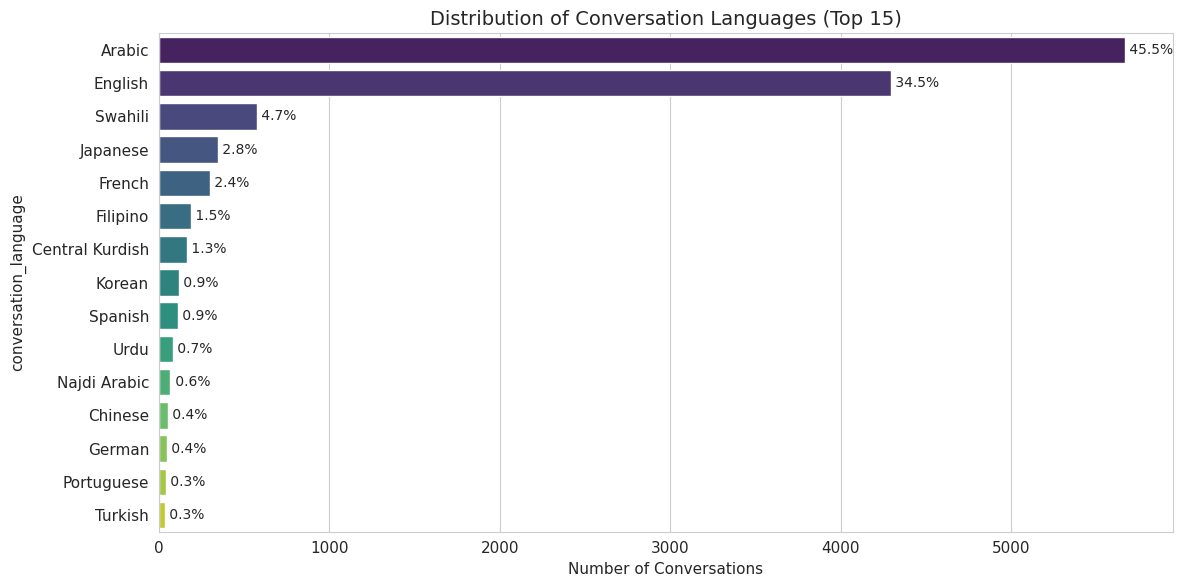

In [10]:

# ---------------------- TOPIC 3 - CELL 2: Language Distribution Chart ---------

plt.figure(figsize=(12, 6))

if len(lang_counts) <= 8:
    # Pie chart for few categories
    plt.pie(lang_counts, labels=lang_counts.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('pastel'),
            explode=[0.05] * len(lang_counts))
    plt.title(f'Language Distribution (Total: {total_convs})', fontsize=14)
else:
    # Horizontal bar chart for many categories
    plot_data = lang_counts.head(15) if len(lang_counts) > 15 else lang_counts
    title_suffix = "(Top 15)" if len(lang_counts) > 15 else ""

    ax = sns.barplot(x=plot_data.values, y=plot_data.index, palette='viridis')
    plt.title(f'Distribution of Conversation Languages {title_suffix}', fontsize=14)
    plt.xlabel('Number of Conversations')

    for i, p in enumerate(ax.patches):
        width = p.get_width()
        ax.text(width + 0.1, p.get_y() + p.get_height()/2,
                f' {width/total_convs:.1%}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('topic3_cell2_language_dist.png', dpi=150, bbox_inches='tight')
plt.show()


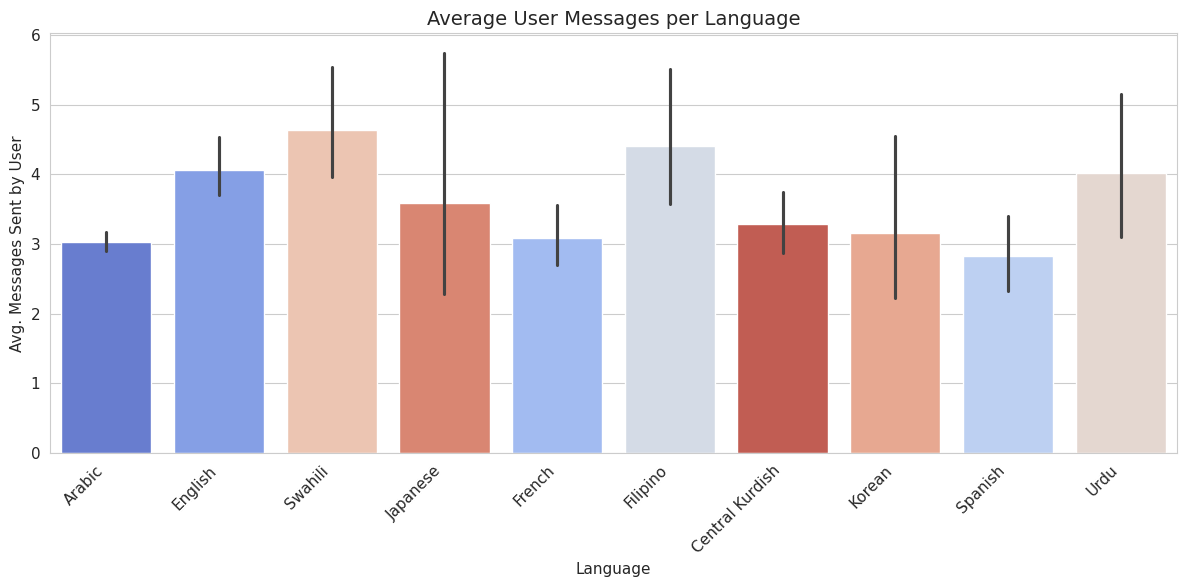

In [11]:

# ---------------------- TOPIC 3 - CELL 3: Avg Messages by Language ------------

# FIXED: Previously used undefined 'top_languages' variable. Now uses 'top_lang_counts'.
plt.figure(figsize=(12, 6))
sns.barplot(x='conversation_language', y='user_msg_count', data=df_top_lang,
            order=top_lang_list, estimator=np.mean, palette='coolwarm',
            hue='conversation_language', legend=False)
plt.title('Average User Messages per Language', fontsize=14)
plt.ylabel('Avg. Messages Sent by User')
plt.xlabel('Language')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('topic3_cell3_avg_msgs_lang.png', dpi=150, bbox_inches='tight')
plt.show()

### 📝 Topic 3 — Key Takeaways

- **80 languages detected**, but **Arabic (45.5%) and English (34.5%) dominate** — together they account for 80% of all conversations.
- **Swahili is third** at 4.7%, likely representing East African users.
- **Engagement by language**: Swahili users are the most engaged (4.6 messages per chat), followed by Filipino (4.4) and English (4.1). Arabic users send the fewest messages (3.0) among the top 10 — possibly because the bot's Arabic responses are comprehensive enough that users don't need follow-ups.
- The remaining 77 languages each contribute less than 3%, but their presence shows the system serves a highly diverse user base.

---

# ⚠️ Topic 4: Bot Failure Analysis — When Did the Bot Go Silent?

**Goal**: Identify conversations where the bot received a message but completely failed to respond (zero bot messages). Classify these failures by severity, find time-based patterns that could indicate server outages, and identify which languages have the highest failure rates.

**Columns used**: `bot_msg_count`, `user_msg_count`, `all_user_messages`, `start_time`, `conversation_language`

This topic has 1 main cell that produces:
- Failure classification (Critical / Frustrated / Low Impact / Empty)
- Time pattern analysis (failures by year, month, hour)
- 3 charts (failures by year, month, hour)
- Failure rate by language + bar chart



⚠️  TOPIC 4: BOT FAILURE REPORT
  Total Silent Conversations: 109
  Overall Failure Rate:       0.88%
------------------------------------------------------------
  Failure Classification:
    ⚪ Empty Conversation (No Messages At All):  0
    🔴 Critical: Ignored Long Query (>=20 chars): 30
    🟠 Frustrated: User tried multiple times:     7
    🟡 Low Impact: Failed Short Greeting:         72
        Total:                                    109
------------------------------------------------------------

  Server Outage Detection (Time of Failures):

  [Failures by Year]
      2024: 7 failures
      2025: 95 failures
      2026: 7 failures

  [Failures by Month]
      February: 30 failures
      January: 30 failures
      March: 23 failures
      October: 10 failures
      November: 4 failures
      April: 3 failures
      June: 3 failures
      September: 3 failures
      August: 2 failures
      May: 1 failures

  [Failures by Hour]
      0:00 → 2 failures
      1:00 → 3 failures
 

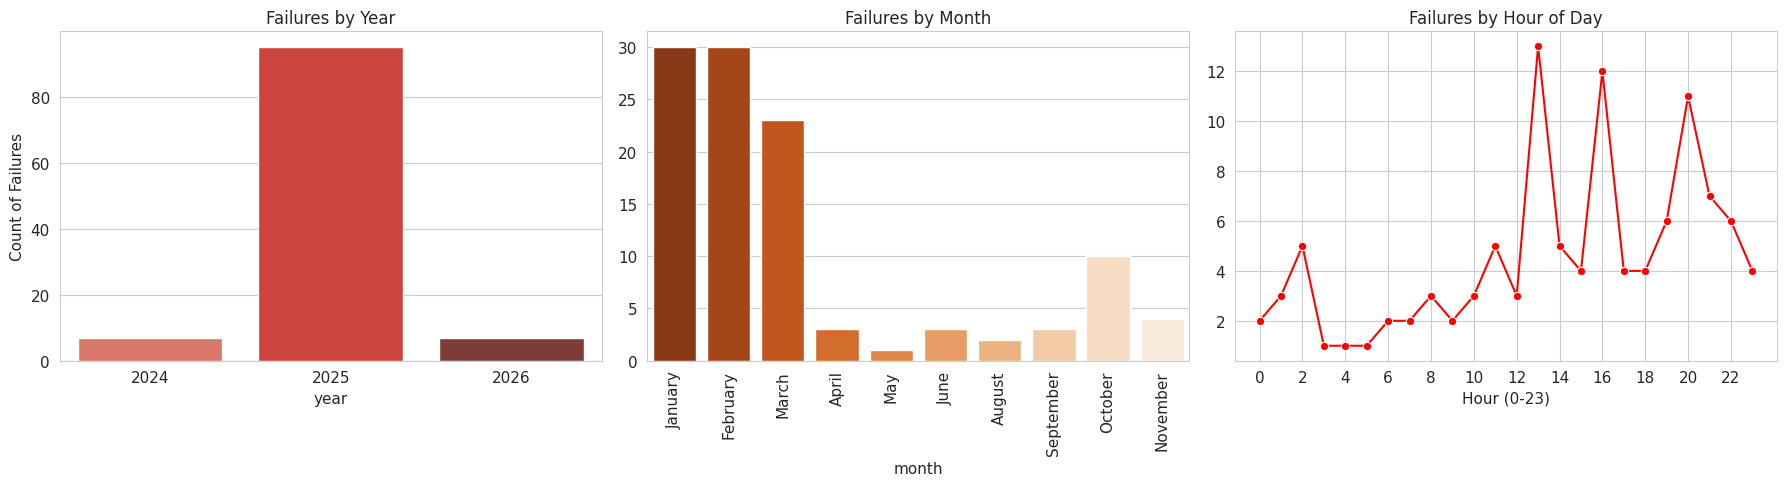


  Failure Rate by Language:
    Arabic: 39 failures (0.7% of all Arabic chats)
    English: 38 failures (0.9% of all English chats)
    Persian: 4 failures (50.0% of all Persian chats)
    No Language: 3 failures (100.0% of all No Language chats)
    Sindhi: 3 failures (100.0% of all Sindhi chats)
    Esperanto: 2 failures (100.0% of all Esperanto chats)
    Undetermined: 2 failures (66.7% of all Undetermined chats)
    French: 2 failures (0.7% of all French chats)
    Polish: 1 failures (25.0% of all Polish chats)
    Maltese: 1 failures (100.0% of all Maltese chats)
    Jamaican Creole English: 1 failures (100.0% of all Jamaican Creole English chats)
    Tok Pisin: 1 failures (100.0% of all Tok Pisin chats)
    Standard Estonian: 1 failures (100.0% of all Standard Estonian chats)
    Spanish: 1 failures (0.9% of all Spanish chats)
    Papiamento: 1 failures (100.0% of all Papiamento chats)
    Urdu: 1 failures (1.2% of all Urdu chats)
    Danish: 1 failures (100.0% of all Danish cha

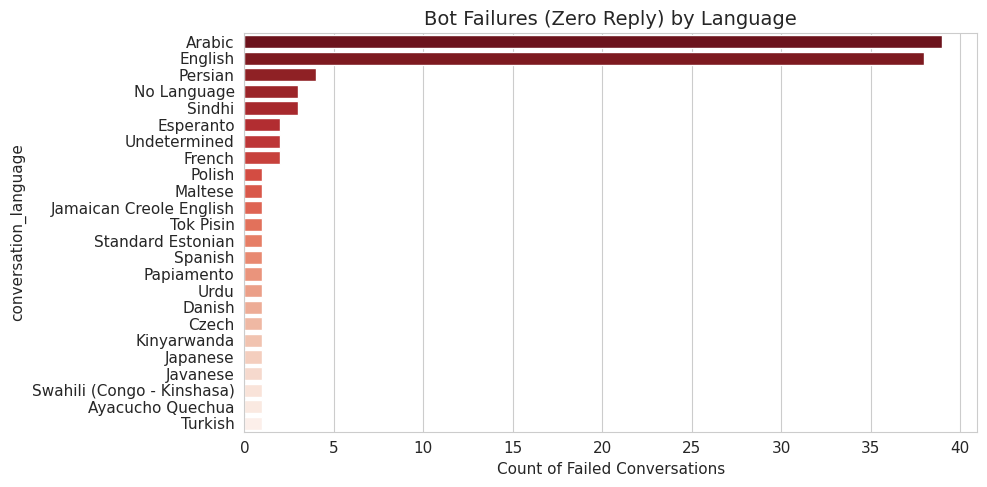

In [12]:

# =============================================================================
# TOPIC 4: BOT FAILURE ANALYSIS (Zero Bot Responses)
# =============================================================================

# ---------------------- TOPIC 4 - CELL 1: Failure Report & Patterns ----------

silent_bot_df = df[df['bot_msg_count'] == 0].copy()
total_failures = len(silent_bot_df)
failure_rate = (total_failures / total_convs) * 100

print("\n")
print("⚠️  TOPIC 4: BOT FAILURE REPORT")
print("=" * 60)
print(f"  Total Silent Conversations: {total_failures}")
print(f"  Overall Failure Rate:       {failure_rate:.2f}%")
print("-" * 60)

if total_failures > 0:
    # --- A. User Behavior Analysis (with Empty Conversation category) ---

    # Category 1: Empty — no messages from either side
    empty_convs = silent_bot_df[silent_bot_df['user_msg_count'] == 0]
    empty_count = len(empty_convs)

    # Remaining: user sent at least one message but bot didn't reply
    user_tried_df = silent_bot_df[silent_bot_df['user_msg_count'] > 0]

    multi_try = user_tried_df[user_tried_df['user_msg_count'] > 1]
    single_try = user_tried_df[user_tried_df['user_msg_count'] == 1]

    single_try_lens = single_try['all_user_messages'].fillna('').astype(str).str.len()
    short_greetings = single_try[single_try_lens < 20].shape[0]
    long_queries = single_try[single_try_lens >= 20].shape[0]
    multi_try_count = multi_try.shape[0]

    print("  Failure Classification:")
    print(f"    ⚪ Empty Conversation (No Messages At All):  {empty_count}")
    print(f"    🔴 Critical: Ignored Long Query (>=20 chars): {long_queries}")
    print(f"    🟠 Frustrated: User tried multiple times:     {multi_try_count}")
    print(f"    🟡 Low Impact: Failed Short Greeting:         {short_greetings}")
    print(f"    {'':4s}Total:                                    {total_failures}")
    print("-" * 60)

    # --- B. Time Pattern Analysis ---
    silent_bot_df['year'] = silent_bot_df['start_time'].dt.year
    silent_bot_df['month'] = silent_bot_df['start_time'].dt.month_name()
    silent_bot_df['hour'] = silent_bot_df['start_hour']

    fail_year = silent_bot_df['year'].value_counts().sort_index()
    fail_month = silent_bot_df['month'].value_counts()
    fail_hour = silent_bot_df['hour'].value_counts().sort_index()

    print("\n  Server Outage Detection (Time of Failures):")

    print("\n  [Failures by Year]")
    for y, c in fail_year.items():
        print(f"      {y}: {c} failures")

    print("\n  [Failures by Month]")
    for m, c in fail_month.items():
        print(f"      {m}: {c} failures")

    print("\n  [Failures by Hour]")
    for h, c in fail_hour.items():
        print(f"      {h}:00 → {c} failures")

    # --- C. Visualization ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.barplot(x=fail_year.index.astype(str), y=fail_year.values, ax=axes[0],
                palette='Reds_d', hue=fail_year.index.astype(str), legend=False)
    axes[0].set_title('Failures by Year', fontsize=12)
    axes[0].set_ylabel('Count of Failures')

    fail_month_ordered = fail_month.reindex(month_order).dropna()
    if len(fail_month_ordered) > 0:
        sns.barplot(x=fail_month_ordered.index, y=fail_month_ordered.values, ax=axes[1],
                    palette='Oranges_r', hue=fail_month_ordered.index, legend=False)
        axes[1].set_title('Failures by Month', fontsize=12)
        axes[1].tick_params(axis='x', rotation=90)

    hours_all = range(0, 24)
    fail_hour_full = fail_hour.reindex(hours_all, fill_value=0)
    sns.lineplot(x=fail_hour_full.index, y=fail_hour_full.values, ax=axes[2],
                 color='red', marker='o')
    axes[2].set_title('Failures by Hour of Day', fontsize=12)
    axes[2].set_xticks(range(0, 24, 2))
    axes[2].set_xlabel('Hour (0-23)')
    axes[2].grid(True)

    plt.tight_layout()
    plt.savefig('topic4_cell1_failure_patterns.png', dpi=150, bbox_inches='tight')
    plt.show()

    # --- D. Failure Rate by Language ---
    print("\n  Failure Rate by Language:")
    all_lang_counts = df['conversation_language'].value_counts()
    fail_lang_counts = silent_bot_df['conversation_language'].value_counts()

    for lang, fail_count in fail_lang_counts.items():
        total_in_lang = all_lang_counts.get(lang, 0)
        lang_fail_rate = (fail_count / total_in_lang) * 100
        print(f"    {lang}: {fail_count} failures ({lang_fail_rate:.1f}% of all {lang} chats)")

    plt.figure(figsize=(10, 5))
    sns.barplot(x=fail_lang_counts.values, y=fail_lang_counts.index, palette='Reds_r')
    plt.title('Bot Failures (Zero Reply) by Language', fontsize=14)
    plt.xlabel('Count of Failed Conversations')
    plt.tight_layout()
    plt.savefig('topic4_cell2_failure_by_lang.png', dpi=150, bbox_inches='tight')
    plt.show()

else:
    print("\n  ✅ Good News: No conversations found where the Bot failed to reply!")
    print("     (Your dataset has 0 cases of bot_msg_count == 0)")
print("=" * 60)

### 📝 Topic 4 — Key Takeaways

- **Overall failure rate: 0.88%** (109 out of 12,448) — the system is generally reliable.
- **30 critical failures**: Users who asked genuine questions (20+ characters) and got zero response. These are the most important to investigate.
- **7 frustrated users**: Sent multiple messages trying to get a response before giving up.
- **72 low-impact**: Users who only sent a short greeting ("Hi", "Salam") — less concerning.
- **January and February concentration**: 60 out of 109 failures (55%) happened in just two months, suggesting a potential system issue during that period. Server logs for these months should be checked.
- **Persian has a 50% failure rate** (4 out of 8 conversations), and several rare languages show 100% failure rates — but with very small sample sizes (1–3 conversations each).

---

# ⚖️ Topic 5: Conversation Balance — Who Talks More?

**Goal**: Measure whether conversations are balanced or lopsided. Is the bot dominating (lecturing)? Is the user dominating (interrogating, possibly because the bot doesn't understand)? A healthy chatbot should show mostly balanced conversations.

**How it works**: For each conversation, we calculate the ratio of bot messages to user messages:
- **Bot Dominant** (ratio > 2.0): Bot sends more than 2× the user's messages
- **Balanced Dialogue** (ratio 0.5–2.0): Roughly equal exchange
- **User Dominant** (ratio < 0.5): User sends more than 2× the bot's messages

**Columns used**: `user_msg_count`, `bot_msg_count`



⚖️  TOPIC 5: CONVERSATION BALANCE REPORT
Category                            | Count      | Percentage
------------------------------------------------------------
Balanced Dialogue                   | 12201      | 98.0%
User Dominant (Interrogating)       | 137        | 1.1%
Silent User (No Reply)              | 100        | 0.8%
Bot Dominant (Lecturing)            | 10         | 0.1%
  Bot Dominant: Bot sends > 2x more messages than User.
  Balanced:     Ratio is between 0.5x and 2x.
  User Dominant: User sends > 2x more messages than Bot.


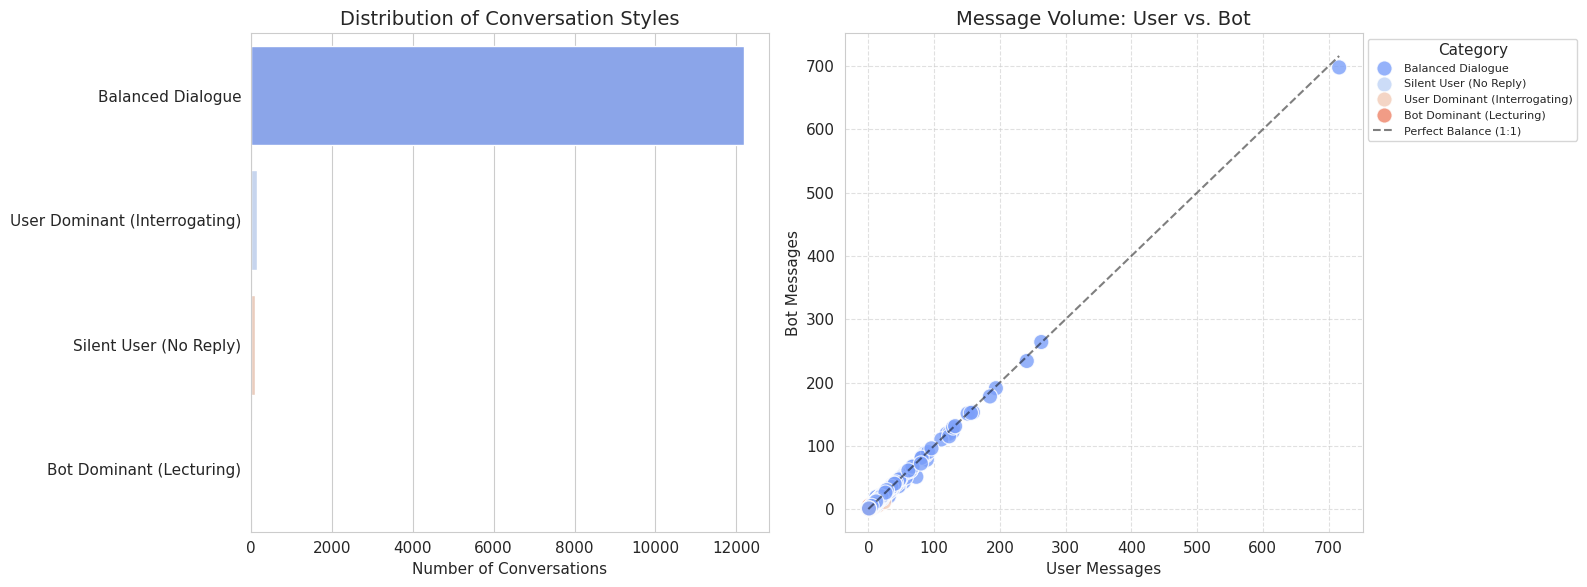

In [13]:

# =============================================================================
# TOPIC 5: CONVERSATION BALANCE (Lecture vs. Dialogue)
# =============================================================================

# ---------------------- TOPIC 5 - CELL 1: Balance Report & Charts ------------

def get_balance_category(row):
    u = row['user_msg_count']
    b = row['bot_msg_count']
    if u == 0:
        return "Silent User (No Reply)"
    ratio = b / u
    if ratio > 2.0:
        return "Bot Dominant (Lecturing)"
    elif ratio < 0.5:
        return "User Dominant (Interrogating)"
    else:
        return "Balanced Dialogue"

df['balance_category'] = df.apply(get_balance_category, axis=1)
balance_counts = df['balance_category'].value_counts()

print("\n")
print("⚖️  TOPIC 5: CONVERSATION BALANCE REPORT")
print("=" * 60)
print(f"{'Category':<35} | {'Count':<10} | {'Percentage':<10}")
print("-" * 60)
for cat, count in balance_counts.items():
    pct = (count / total_convs) * 100
    print(f"{cat:<35} | {count:<10} | {pct:.1f}%")
print("=" * 60)
print("  Bot Dominant: Bot sends > 2x more messages than User.")
print("  Balanced:     Ratio is between 0.5x and 2x.")
print("  User Dominant: User sends > 2x more messages than Bot.")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A. Category Count
sns.countplot(y='balance_category', data=df, order=balance_counts.index,
              palette='coolwarm', ax=axes[0])
axes[0].set_title('Distribution of Conversation Styles', fontsize=14)
axes[0].set_xlabel('Number of Conversations')
axes[0].set_ylabel('')

# B. Scatter Plot (User vs Bot)
sns.scatterplot(x='user_msg_count', y='bot_msg_count', hue='balance_category',
                data=df, s=120, palette='coolwarm', ax=axes[1], alpha=0.8)

max_val = max(df['user_msg_count'].max(), df['bot_msg_count'].max())
axes[1].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Perfect Balance (1:1)')

axes[1].set_title('Message Volume: User vs. Bot', fontsize=14)
axes[1].set_xlabel('User Messages')
axes[1].set_ylabel('Bot Messages')
axes[1].legend(title='Category', loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('topic5_balance.png', dpi=150, bbox_inches='tight')
plt.show()

### 📝 Topic 5 — Key Takeaways

- **98% of conversations are balanced** — an excellent sign that the bot engages naturally.
- **137 user-dominant cases (1.1%)**: The user sent many more messages than the bot replied. This could indicate the user had to rephrase their question multiple times because the bot didn't understand. These cases deserve further investigation.
- **Only 10 bot-dominant cases (0.1%)**: Very rare — the bot almost never "lectures."

---

# 🕐 Topic 6: Peak Interaction Times by Language

**Goal**: Find out when each major language community is most active. Different languages reflect different geographic regions and time zones, so their activity patterns differ.

**Columns used**: `conversation_language`, `start_time`, `start_hour`, `day_of_week`

This cell runs the `analyze_yearly_peaks()` function for each year in the dataset. For each year, it:
- Identifies the top 4 languages by volume
- Reports the peak month, day, and hour for each language
- Generates 3 charts: monthly seasonality, weekly routine, hourly routine — all broken down by language



📊 TOPIC 6: PEAK INTERACTION TIMES BY LANGUAGE
  Found data for years: [np.int32(2024), np.int32(2025), np.int32(2026)]

📅 DETAILED REPORT FOR YEAR: 2024
  Top 4 Languages analyzed: English, Arabic, No Language, Najdi Arabic

  🌍 ENGLISH (123 chats):
     Peak Season: October
     Peak Day:    Friday
     Peak Time:   1:00
----------------------------------------
  🌍 ARABIC (51 chats):
     Peak Season: October
     Peak Day:    Friday
     Peak Time:   17:00
----------------------------------------
  🌍 NO LANGUAGE (1 chats):
     Peak Season: October
     Peak Day:    Thursday
     Peak Time:   22:00
----------------------------------------
  🌍 NAJDI ARABIC (1 chats):
     Peak Season: October
     Peak Day:    Friday
     Peak Time:   1:00
----------------------------------------


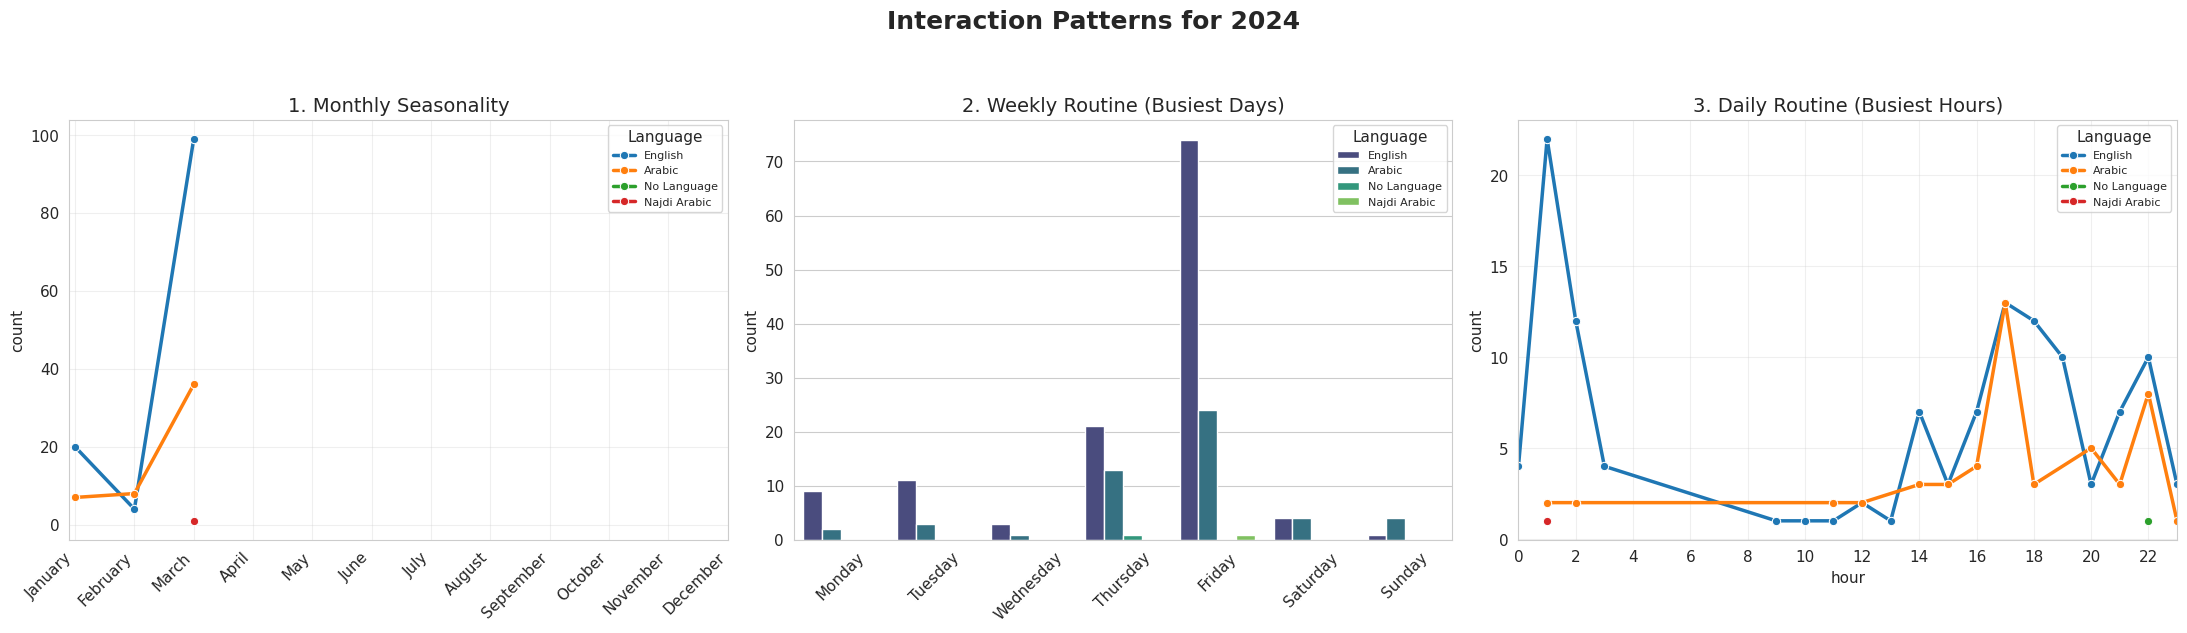


📅 DETAILED REPORT FOR YEAR: 2025
  Top 4 Languages analyzed: Arabic, English, Swahili, Japanese

  🌍 ARABIC (5211 chats):
     Peak Season: March
     Peak Day:    Thursday
     Peak Time:   14:00
----------------------------------------
  🌍 ENGLISH (3693 chats):
     Peak Season: March
     Peak Day:    Thursday
     Peak Time:   14:00
----------------------------------------
  🌍 SWAHILI (493 chats):
     Peak Season: June
     Peak Day:    Saturday
     Peak Time:   20:00
----------------------------------------
  🌍 JAPANESE (316 chats):
     Peak Season: September
     Peak Day:    Tuesday
     Peak Time:   4:00
----------------------------------------


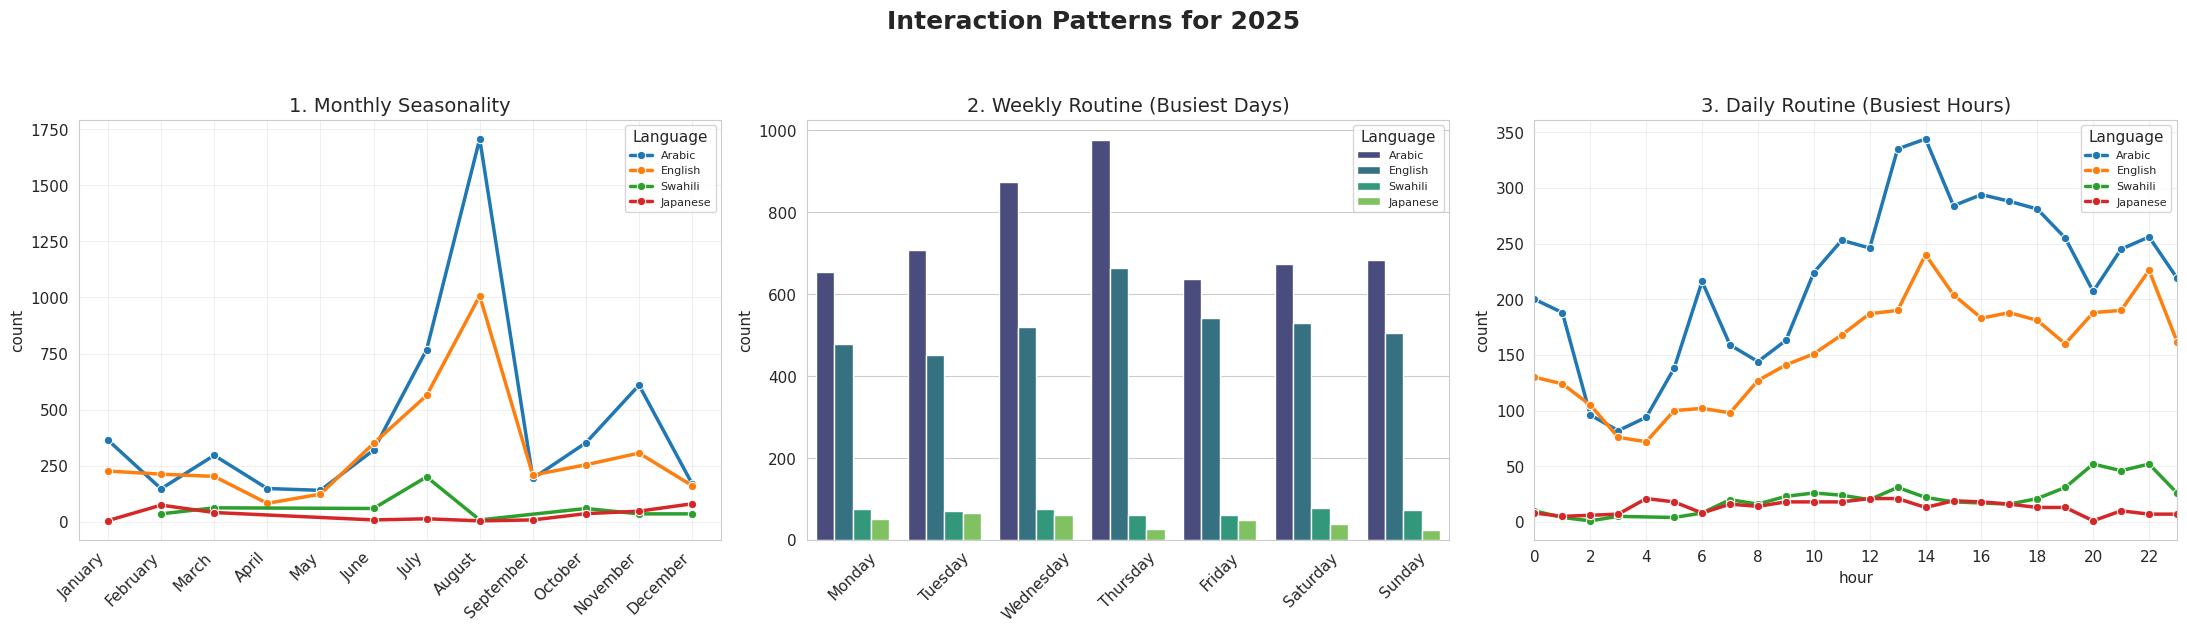


📅 DETAILED REPORT FOR YEAR: 2026
  Top 4 Languages analyzed: English, Arabic, French, Swahili

  🌍 ENGLISH (477 chats):
     Peak Season: January
     Peak Day:    Friday
     Peak Time:   16:00
----------------------------------------
  🌍 ARABIC (405 chats):
     Peak Season: January
     Peak Day:    Monday
     Peak Time:   22:00
----------------------------------------
  🌍 FRENCH (93 chats):
     Peak Season: March
     Peak Day:    Friday
     Peak Time:   21:00
----------------------------------------
  🌍 SWAHILI (86 chats):
     Peak Season: January
     Peak Day:    Monday
     Peak Time:   19:00
----------------------------------------


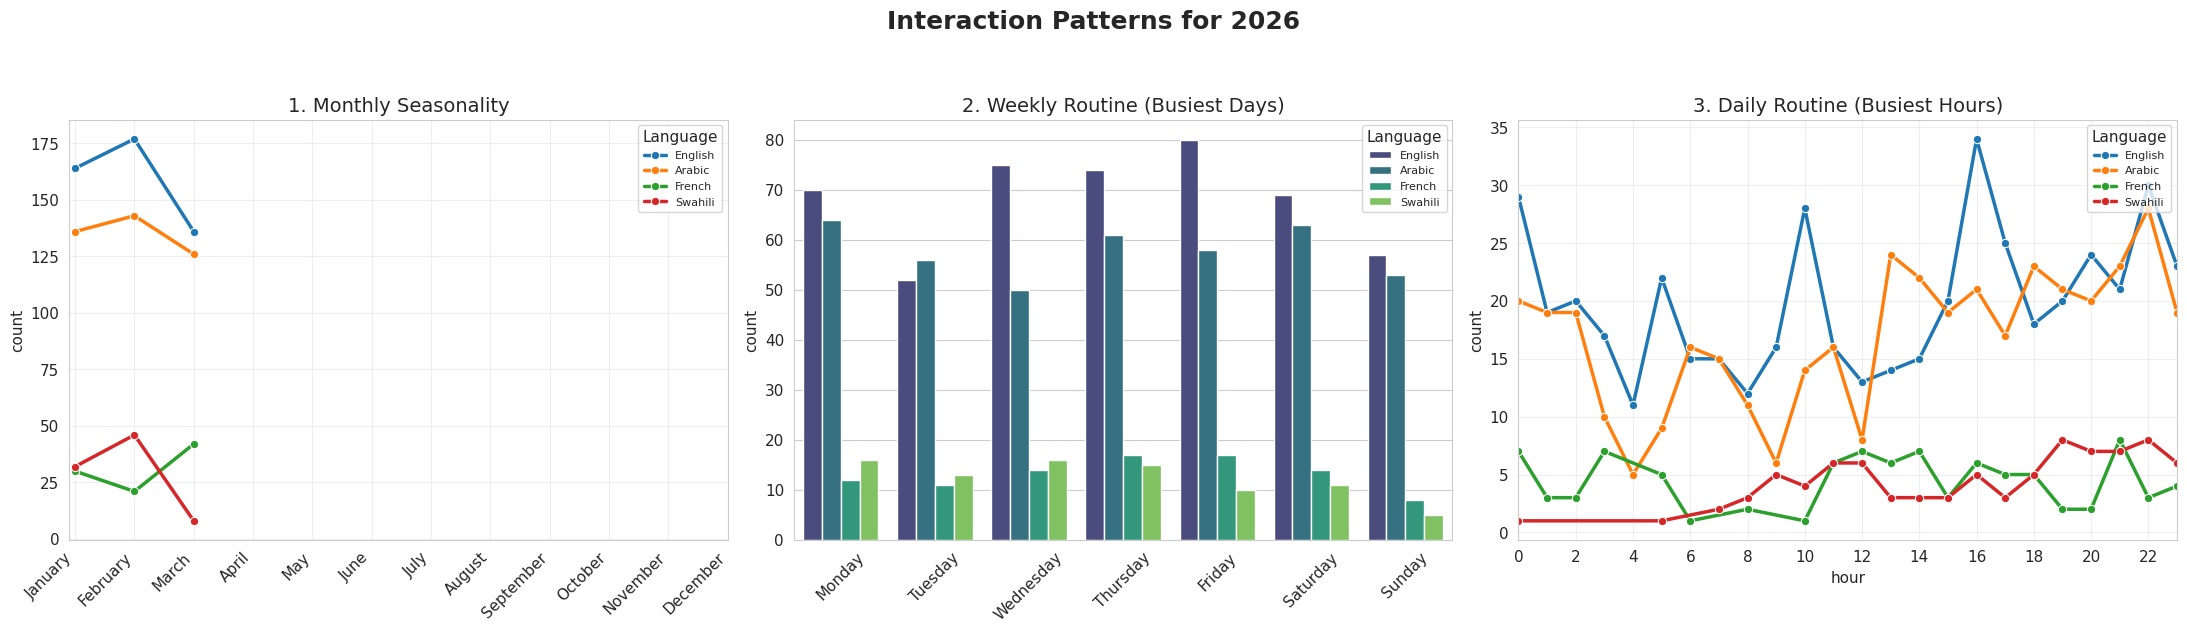

In [14]:

# =============================================================================
# TOPIC 6: PEAK INTERACTION TIMES BY LANGUAGE
# =============================================================================

# ---------------------- TOPIC 6 - CELL 1: Function + Execution ---------------

def analyze_yearly_peaks(target_year, df_data, top_n_languages=4):
    """
    Generates a detailed report and 3 charts for a specific year,
    showing interaction patterns per language.
    """
    year_df = df_data[df_data['year'] == target_year].copy()

    if len(year_df) == 0:
        print(f"  ⚠️ No data found for year {target_year}")
        return

    # Identify top languages present IN THIS YEAR
    top_langs = year_df['conversation_language'].value_counts().nlargest(top_n_languages).index.tolist()

    print(f"\n{'='*80}")
    print(f"📅 DETAILED REPORT FOR YEAR: {target_year}")
    print(f"{'='*80}")
    print(f"  Top {len(top_langs)} Languages analyzed: {', '.join(top_langs)}\n")

    for lang in top_langs:
        lang_df = year_df[year_df['conversation_language'] == lang]
        if len(lang_df) == 0:
            continue

        peak_month = lang_df['month_name'].mode()[0]
        peak_day = lang_df['day_name'].mode()[0]
        peak_hour = lang_df['hour'].mode()[0]
        total_chats = len(lang_df)

        print(f"  🌍 {lang.upper()} ({total_chats} chats):")
        print(f"     Peak Season: {peak_month}")
        print(f"     Peak Day:    {peak_day}")
        print(f"     Peak Time:   {peak_hour}:00")
        print("-" * 40)

    # --- Visualization (3 Subplots) ---
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle(f'Interaction Patterns for {target_year}', fontsize=18, fontweight='bold', y=1.05)

    plot_df = year_df[year_df['conversation_language'].isin(top_langs)]

    # 1. Monthly Trend
    month_counts = plot_df.groupby(['month_name', 'conversation_language']).size().reset_index(name='count')
    sns.lineplot(data=month_counts, x='month_name', y='count', hue='conversation_language',
                 hue_order=top_langs, marker='o', ax=axes[0], palette='tab10', linewidth=2.5)
    axes[0].set_title('1. Monthly Seasonality', fontsize=14)
    axes[0].set_xticks(range(len(month_order)))
    axes[0].set_xticklabels(month_order, rotation=45, ha='right')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlabel('')
    axes[0].legend(title='Language', loc='upper right', fontsize=8)

    # 2. Daily Pattern
    day_counts = plot_df.groupby(['day_name', 'conversation_language']).size().reset_index(name='count')
    day_counts['day_name'] = pd.Categorical(day_counts['day_name'], categories=day_order, ordered=True)

    sns.barplot(data=day_counts, x='day_name', y='count', hue='conversation_language',
                hue_order=top_langs, ax=axes[1], palette='viridis')
    axes[1].set_title('2. Weekly Routine (Busiest Days)', fontsize=14)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_xlabel('')
    axes[1].legend(title='Language', loc='upper right', fontsize=8)

    # 3. Hourly Routine
    hour_counts = plot_df.groupby(['hour', 'conversation_language']).size().reset_index(name='count')
    sns.lineplot(data=hour_counts, x='hour', y='count', hue='conversation_language',
                 hue_order=top_langs, marker='o', ax=axes[2], palette='tab10', linewidth=2.5)
    axes[2].set_title('3. Daily Routine (Busiest Hours)', fontsize=14)
    axes[2].set_xticks(range(0, 24, 2))
    axes[2].set_xlim(0, 23)
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(title='Language', loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.savefig(f'topic6_peaks_{target_year}.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- Execute for each year ---
available_years = sorted(df['year'].dropna().unique())
print("\n")
print("📊 TOPIC 6: PEAK INTERACTION TIMES BY LANGUAGE")
print(f"  Found data for years: {available_years}")

for year in available_years:
    analyze_yearly_peaks(year, df)

### 📝 Topic 6 — Key Takeaways

- **Arabic and English share the same peak** in 2025 (Thursday at 2:00 PM), suggesting users are in the same geographic region (likely the Middle East).
- **Swahili peaks on Saturday evenings at 8:00 PM** — this pattern indicates personal/recreational use rather than work-related.
- **Japanese peaks at 4:00 AM system time**, which corresponds to afternoon in Japan — confirming a different time zone entirely.
- **French emerged as the 3rd largest language in Q1 2026** (replacing Japanese), peaking Friday evenings at 9:00 PM. This signals a growing user base in francophone Africa.

---

# ⏱️ Topic 7: Response Time Analysis — How Fast Is the Bot?

**Goal**: Measure how quickly the AI bot responds to users, and how quickly users respond to the bot. Response time is one of the most critical quality metrics — slow responses lead to user abandonment.

**Columns used**: `avg_response_time_ai_sec`, `avg_response_time_user_sec`, `user_msg_count`

**⚠️ Outlier handling**: The raw data contains extreme outliers (max AI response time = 24 days, max user response time = 71 days). These are clearly system errors. The analysis shows both raw and cleaned statistics, using a **99th percentile cap** to filter out the top 1% of extreme values.

This topic has 2 cells:

| Cell | What It Does |
|------|-------------|
| 7.1 | Text report — raw vs cleaned stats, speed categories |
| 7.2 | 4 charts — AI response distribution, user response distribution, speed vs engagement scatter, AI vs user box plot (log scale) |

In [15]:

# =============================================================================
# TOPIC 7: RESPONSE TIME ANALYSIS (NEW) — WITH OUTLIER HANDLING
# =============================================================================

# ---------------------- TOPIC 7 - CELL 1: Response Time Report ---------------

ai_response = df['avg_response_time_ai_sec'].dropna()
user_response = df['avg_response_time_user_sec'].dropna()

# Calculate percentile thresholds for outlier detection
ai_p99 = ai_response.quantile(0.99)
user_p99 = user_response.quantile(0.99)

# Cleaned versions (capped at 99th percentile)
ai_clean = ai_response[ai_response <= ai_p99]
user_clean = user_response[user_response <= user_p99]

print("\n")
print("⏱️  TOPIC 7: RESPONSE TIME ANALYSIS REPORT")
print("=" * 60)

print("\n  📍 AI Bot Response Time:")
print(f"     Conversations with data: {len(ai_response)} out of {total_convs}")
print(f"     ┌─ RAW (includes outliers):")
print(f"     │  Mean:   {ai_response.mean():.2f} sec")
print(f"     │  Median: {ai_response.median():.2f} sec")
print(f"     │  Max:    {ai_response.max():.2f} sec")
print(f"     ├─ CLEANED (99th percentile cap at {ai_p99:.2f}s):")
print(f"     │  Mean:   {ai_clean.mean():.2f} sec")
print(f"     │  Median: {ai_clean.median():.2f} sec")
print(f"     │  Max:    {ai_clean.max():.2f} sec")
print(f"     └─ Outliers removed: {len(ai_response) - len(ai_clean)} conversations")

print(f"\n  📍 User Response Time:")
print(f"     Conversations with data: {len(user_response)} out of {total_convs}")
print(f"     ┌─ RAW (includes outliers):")
print(f"     │  Mean:   {user_response.mean():.2f} sec")
print(f"     │  Median: {user_response.median():.2f} sec")
print(f"     │  Max:    {user_response.max():.2f} sec")
print(f"     ├─ CLEANED (99th percentile cap at {user_p99:.2f}s):")
print(f"     │  Mean:   {user_clean.mean():.2f} sec")
print(f"     │  Median: {user_clean.median():.2f} sec")
print(f"     │  Max:    {user_clean.max():.2f} sec")
print(f"     └─ Outliers removed: {len(user_response) - len(user_clean)} conversations")

# Speed categories for AI
def categorize_ai_speed(sec):
    if pd.isna(sec): return 'N/A (No AI Reply)'
    elif sec <= 1: return 'Instant (<=1s)'
    elif sec <= 5: return 'Fast (1-5s)'
    elif sec <= 15: return 'Normal (5-15s)'
    else: return 'Slow (>15s)'

df['ai_speed_category'] = df['avg_response_time_ai_sec'].apply(categorize_ai_speed)
speed_counts = df['ai_speed_category'].value_counts()

print("\n  📍 AI Speed Categories:")
for cat, count in speed_counts.items():
    print(f"     {cat}: {count} ({count/total_convs:.1%})")
print("=" * 60)





⏱️  TOPIC 7: RESPONSE TIME ANALYSIS REPORT

  📍 AI Bot Response Time:
     Conversations with data: 12230 out of 12448
     ┌─ RAW (includes outliers):
     │  Mean:   184.98 sec
     │  Median: 0.33 sec
     │  Max:    2088585.18 sec
     ├─ CLEANED (99th percentile cap at 83.52s):
     │  Mean:   4.01 sec
     │  Median: 0.33 sec
     │  Max:    83.33 sec
     └─ Outliers removed: 123 conversations

  📍 User Response Time:
     Conversations with data: 7462 out of 12448
     ┌─ RAW (includes outliers):
     │  Mean:   7801.71 sec
     │  Median: 59.50 sec
     │  Max:    6146671.00 sec
     ├─ CLEANED (99th percentile cap at 125785.60s):
     │  Mean:   1195.33 sec
     │  Median: 59.00 sec
     │  Max:    123257.06 sec
     └─ Outliers removed: 75 conversations

  📍 AI Speed Categories:
     Instant (<=1s): 9535 (76.6%)
     Slow (>15s): 1095 (8.8%)
     Normal (5-15s): 881 (7.1%)
     Fast (1-5s): 719 (5.8%)
     N/A (No AI Reply): 218 (1.8%)


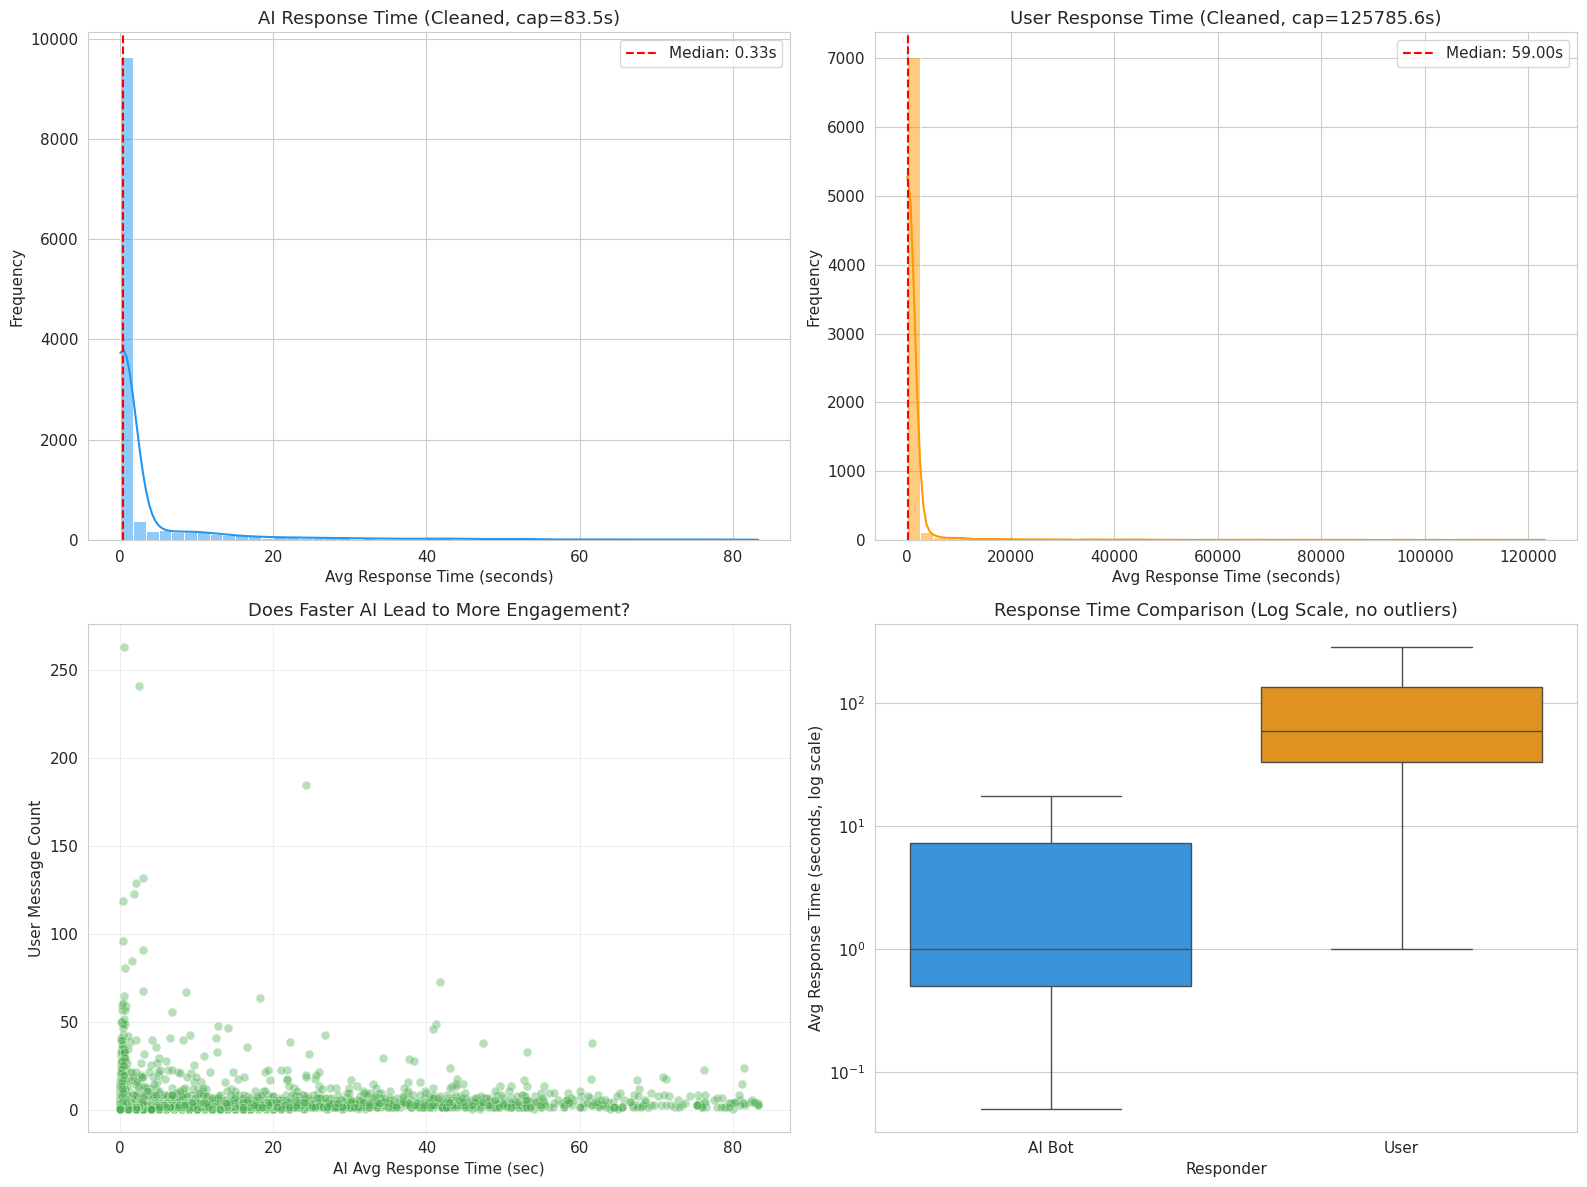

In [16]:

# ---------------------- TOPIC 7 - CELL 2: Visualizations (Cleaned) -----------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A. AI Response Time Distribution (CLEANED)
if len(ai_clean) > 0:
    sns.histplot(ai_clean, bins=50, kde=True, color='#2196F3', ax=axes[0, 0])
    axes[0, 0].set_title(f'AI Response Time (Cleaned, cap={ai_p99:.1f}s)', fontsize=13)
    axes[0, 0].set_xlabel('Avg Response Time (seconds)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(ai_clean.median(), color='red', linestyle='--',
                       label=f'Median: {ai_clean.median():.2f}s')
    axes[0, 0].legend()

# B. User Response Time Distribution (CLEANED)
if len(user_clean) > 0:
    sns.histplot(user_clean, bins=50, kde=True, color='#FF9800', ax=axes[0, 1])
    axes[0, 1].set_title(f'User Response Time (Cleaned, cap={user_p99:.1f}s)', fontsize=13)
    axes[0, 1].set_xlabel('Avg Response Time (seconds)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].axvline(user_clean.median(), color='red', linestyle='--',
                       label=f'Median: {user_clean.median():.2f}s')
    axes[0, 1].legend()

# C. AI Speed vs User Engagement (CLEANED, scatter)
df_valid = df.dropna(subset=['avg_response_time_ai_sec']).copy()
df_valid_clean = df_valid[df_valid['avg_response_time_ai_sec'] <= ai_p99]
if len(df_valid_clean) > 0:
    sns.scatterplot(x='avg_response_time_ai_sec', y='user_msg_count', data=df_valid_clean,
                    s=40, alpha=0.4, color='#4CAF50', ax=axes[1, 0])
    axes[1, 0].set_title('Does Faster AI Lead to More Engagement?', fontsize=13)
    axes[1, 0].set_xlabel('AI Avg Response Time (sec)')
    axes[1, 0].set_ylabel('User Message Count')
    axes[1, 0].grid(True, alpha=0.3)

# D. Box Plot with LOG SCALE (to handle range difference)
response_data = pd.DataFrame({
    'AI Bot': ai_response[ai_response > 0],
    'User': user_response[user_response > 0]
}).melt(var_name='Responder', value_name='Seconds')

if len(response_data) > 0:
    sns.boxplot(x='Responder', y='Seconds', data=response_data,
                palette=['#2196F3', '#FF9800'], ax=axes[1, 1], showfliers=False)
    axes[1, 1].set_yscale('log')
    axes[1, 1].set_title('Response Time Comparison (Log Scale, no outliers)', fontsize=13)
    axes[1, 1].set_ylabel('Avg Response Time (seconds, log scale)')

plt.tight_layout()
plt.savefig('topic7_response_time.png', dpi=150, bbox_inches='tight')
plt.show()

### 📝 Topic 7 — Key Takeaways

- **Outlier impact is massive**: The raw mean AI response time is 185 seconds, but after removing 123 outliers (1%), the cleaned mean drops to just 4.0 seconds. The median is unaffected at 0.33 seconds — always look at the median for response time data.
- **76.6% of responses are instant** (under 1 second) — excellent for user experience.
- **8.8% are slow** (over 15 seconds) — these 1,095 conversations may have caused user frustration.
- **User response time median is 59 seconds** — natural reading and thinking time. The cleaned mean is ~20 minutes, reflecting that some users leave and come back.

---

# 🔄 Topic 8: Session & Gap Analysis — Do Users Come Back?

**Goal**: Understand conversation continuity. A "session" is a period of continuous interaction. A gap of **7 hours or more** between consecutive messages triggers a new session within the same conversation. This tells us whether users have ongoing, multi-day relationships with the bot.

**Columns used**: `num_sessions`, `max_gap_sec`, `total_messages`, `user_msg_count`

This topic has 2 cells:

| Cell | What It Does |
|------|-------------|
| 8.1 | Session report — distribution, gap statistics, engagement comparison (text) |
| 8.2 | 4 charts — session count bar, gap histogram (filtered to <1 hour), gap categories, sessions vs total messages box plot |

In [17]:

# =============================================================================
# TOPIC 8: SESSION & GAP ANALYSIS (NEW) — WITH OUTLIER HANDLING
# =============================================================================

# ---------------------- TOPIC 8 - CELL 1: Session Report ---------------------

session_counts = df['num_sessions'].value_counts().sort_index()
single_session = df[df['num_sessions'] == 1].shape[0]
multi_session = df[df['num_sessions'] > 1].shape[0]

gap_data = df['max_gap_sec'].dropna()

print("\n")
print("🔄 TOPIC 8: SESSION & GAP ANALYSIS REPORT")
print("=" * 60)

print("\n  📍 Session Distribution:")
print(f"     Single Session (1):  {single_session} ({single_session/total_convs:.1%})")
print(f"     Multi-Session (>1):  {multi_session} ({multi_session/total_convs:.1%})")
print("-" * 40)
print("     Breakdown:")
for sess, count in session_counts.items():
    print(f"       {sess} session(s): {count} conversations")

print(f"\n  📍 Gap Statistics (seconds):")
print(f"     Mean max gap:   {gap_data.mean():.1f} sec ({gap_data.mean()/60:.1f} min)")
print(f"     Median max gap: {gap_data.median():.1f} sec ({gap_data.median()/60:.1f} min)")
print(f"     Max gap found:  {gap_data.max():.1f} sec ({gap_data.max()/3600:.1f} hours)")

def categorize_gap(sec):
    if sec == 0: return 'Instant (0s)'
    elif sec <= 60: return 'Under 1 min'
    elif sec <= 300: return '1-5 min'
    elif sec <= 3600: return '5-60 min'
    elif sec <= 25200: return '1-7 hours'
    else: return '7+ hours (New Session)'

df['gap_category'] = df['max_gap_sec'].apply(categorize_gap)
gap_cat_order = ['Instant (0s)', 'Under 1 min', '1-5 min', '5-60 min', '1-7 hours', '7+ hours (New Session)']
gap_cat_counts = df['gap_category'].value_counts().reindex(gap_cat_order).fillna(0).astype(int)

print(f"\n  📍 Max Gap Categories:")
for cat, count in gap_cat_counts.items():
    if count > 0:
        print(f"     {cat}: {count} ({count/total_convs:.1%})")

single_avg_msgs = df[df['num_sessions'] == 1]['total_messages'].mean()
multi_avg_msgs = df[df['num_sessions'] > 1]['total_messages'].mean() if multi_session > 0 else 0

print(f"\n  📍 Engagement Comparison:")
print(f"     Single-session avg messages: {single_avg_msgs:.1f}")
print(f"     Multi-session avg messages:  {multi_avg_msgs:.1f}")
print("=" * 60)




🔄 TOPIC 8: SESSION & GAP ANALYSIS REPORT

  📍 Session Distribution:
     Single Session (1):  12091 (97.1%)
     Multi-Session (>1):  357 (2.9%)
----------------------------------------
     Breakdown:
       1 session(s): 12091 conversations
       2 session(s): 219 conversations
       3 session(s): 50 conversations
       4 session(s): 22 conversations
       5 session(s): 9 conversations
       6 session(s): 5 conversations
       7 session(s): 6 conversations
       8 session(s): 7 conversations
       9 session(s): 7 conversations
       10 session(s): 3 conversations
       11 session(s): 3 conversations
       12 session(s): 3 conversations
       14 session(s): 2 conversations
       15 session(s): 3 conversations
       16 session(s): 3 conversations
       17 session(s): 1 conversations
       18 session(s): 1 conversations
       20 session(s): 1 conversations
       21 session(s): 2 conversations
       22 session(s): 2 conversations
       27 session(s): 1 conversations

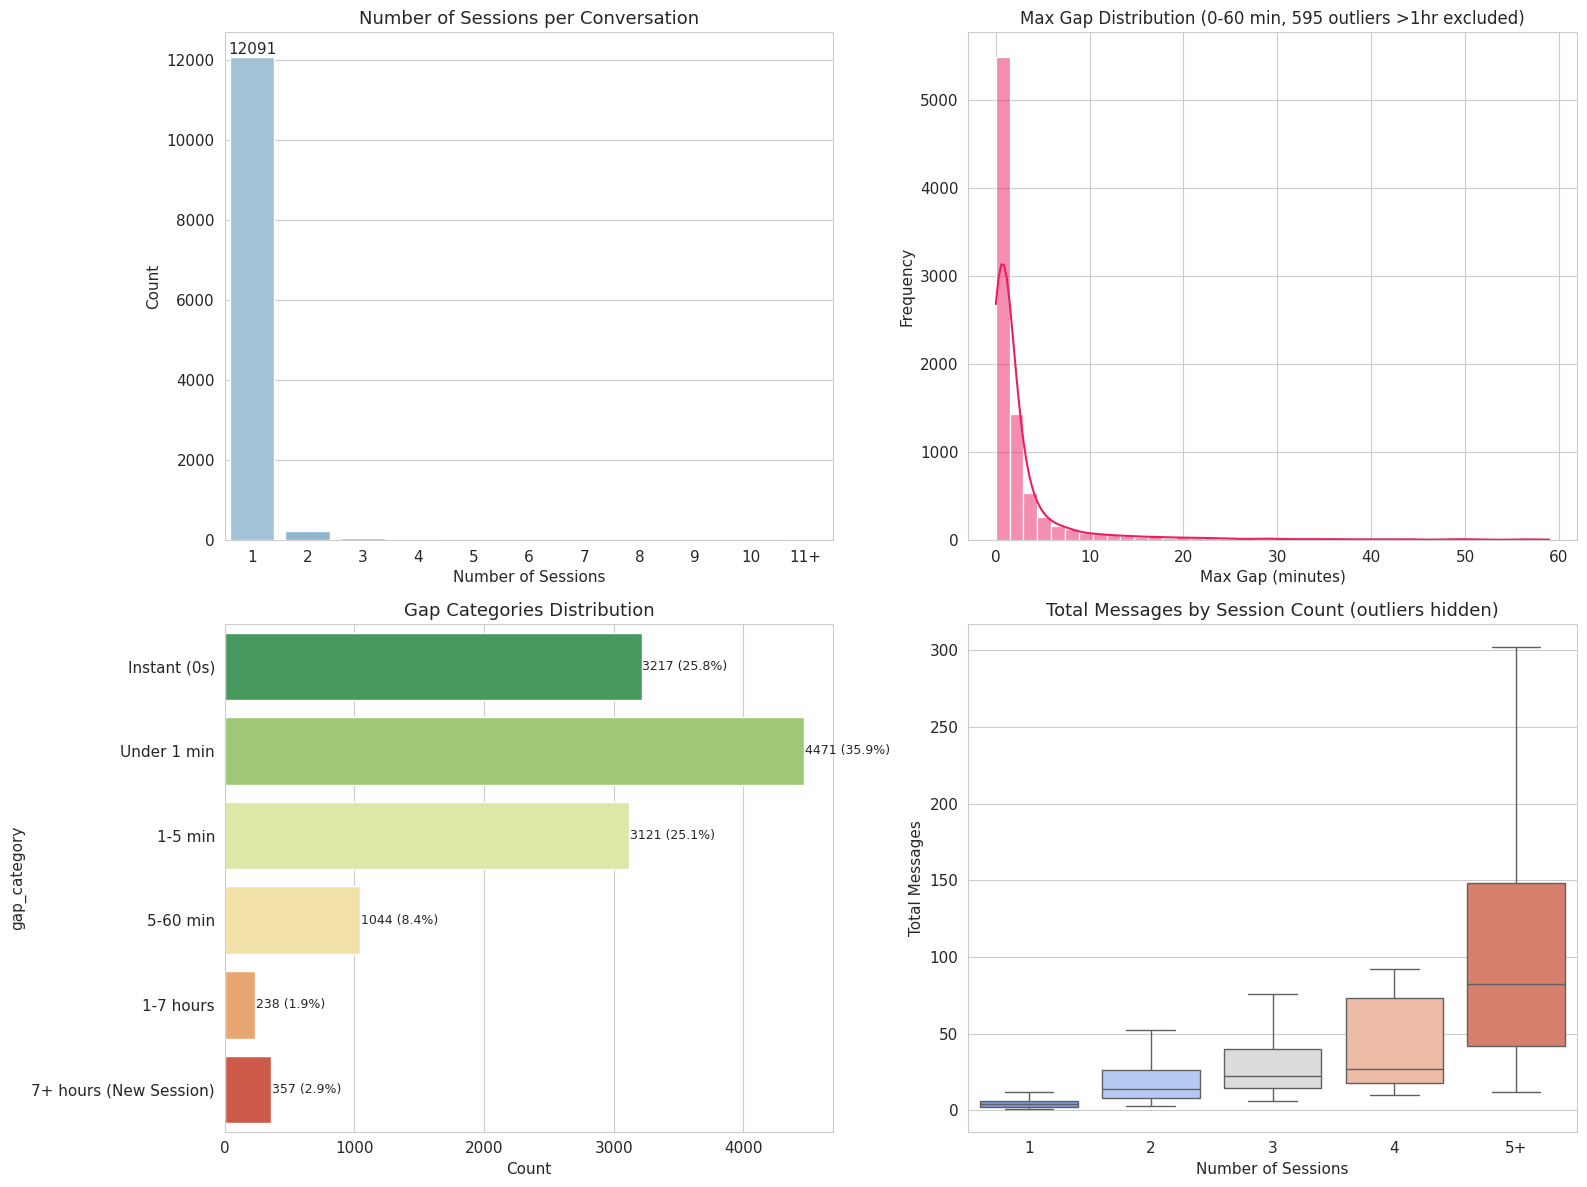

In [18]:

# ---------------------- TOPIC 8 - CELL 2: Visualizations ---------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A. Session Distribution (Bar) — cap display at 10 sessions for readability
session_display = session_counts.copy()
if len(session_counts) > 10:
    top_sessions = session_counts.head(10)
    overflow = session_counts.iloc[10:].sum()
    top_sessions['11+'] = overflow
    session_display = top_sessions

sns.barplot(x=session_display.index.astype(str), y=session_display.values,
            palette='Blues_d', ax=axes[0, 0], hue=session_display.index.astype(str), legend=False)
axes[0, 0].set_title('Number of Sessions per Conversation', fontsize=13)
axes[0, 0].set_xlabel('Number of Sessions')
axes[0, 0].set_ylabel('Count')
axes[0, 0].bar_label(axes[0, 0].containers[0])

# B. Max Gap Distribution — FILTERED to under 1 hour for readability
gaps_under_1hr = df[(df['max_gap_sec'] > 0) & (df['max_gap_sec'] <= 3600)]['max_gap_sec']
gaps_over_1hr = df[df['max_gap_sec'] > 3600].shape[0]

if len(gaps_under_1hr) > 0:
    sns.histplot(gaps_under_1hr / 60, bins=40, kde=True, color='#E91E63', ax=axes[0, 1])
    axes[0, 1].set_title(f'Max Gap Distribution (0-60 min, {gaps_over_1hr} outliers >1hr excluded)', fontsize=12)
    axes[0, 1].set_xlabel('Max Gap (minutes)')
    axes[0, 1].set_ylabel('Frequency')
else:
    axes[0, 1].set_title('Max Gap Distribution (No Data in Range)')

# C. Gap Categories (Horizontal Bar)
active_cats = gap_cat_counts[gap_cat_counts > 0]
if len(active_cats) > 0:
    sns.barplot(x=active_cats.values, y=active_cats.index, palette='RdYlGn_r', ax=axes[1, 0])
    axes[1, 0].set_title('Gap Categories Distribution', fontsize=13)
    axes[1, 0].set_xlabel('Count')
    for i, p in enumerate(axes[1, 0].patches):
        w = p.get_width()
        axes[1, 0].text(w + 5, p.get_y() + p.get_height()/2,
                        f'{int(w)} ({int(w)/total_convs:.1%})', va='center', fontsize=9)

# D. Sessions vs Total Messages (Box, capped for readability)
if multi_session > 0:
    # Group sessions: 1, 2, 3, 4, 5+
    df['session_group'] = df['num_sessions'].apply(lambda x: str(x) if x <= 4 else '5+')
    session_group_order = ['1', '2', '3', '4', '5+']
    existing_groups = [g for g in session_group_order if g in df['session_group'].values]

    sns.boxplot(x='session_group', y='total_messages', data=df,
                order=existing_groups, palette='coolwarm', ax=axes[1, 1],
                showfliers=False)
    axes[1, 1].set_title('Total Messages by Session Count (outliers hidden)', fontsize=13)
    axes[1, 1].set_xlabel('Number of Sessions')
    axes[1, 1].set_ylabel('Total Messages')
else:
    sns.histplot(df['total_messages'], bins=20, kde=True, color='#3F51B5', ax=axes[1, 1])
    axes[1, 1].set_title('Total Messages Distribution (All Single-Session)', fontsize=13)
    axes[1, 1].set_xlabel('Total Messages')

plt.tight_layout()
plt.savefig('topic8_sessions_gaps.png', dpi=150, bbox_inches='tight')
plt.show()

### 📝 Topic 8 — Key Takeaways

- **97.1% of conversations happen in a single sitting** — users start, ask, and finish without interruption.
- **2.9% span multiple sessions** (357 conversations). Most have 2 sessions, but extreme cases reach up to 78 sessions.
- **Multi-session users are 8× more engaged**: They average 47.2 messages vs 5.8 for single-session users. These represent the most complex and important use cases.
- **Gap patterns**: 61.7% have gaps under 1 minute, 8.4% have 5–60 minute gaps (multitasking), and 2.9% have 7+ hour gaps (user left and came back later).
- **The gap histogram is filtered** to show only gaps under 1 hour for readability — the raw max gap is 265 days (clearly a system artifact).

---

# 🎯 Topic 9: Language Detection Confidence

**Goal**: Evaluate how reliable the automatic language detection is. Each conversation has a `language_confidence_score` from 0.0 (no confidence) to 1.0 (completely certain). Low confidence means the detected language may be wrong — which affects the accuracy of all language-based analyses in this notebook.

**Columns used**: `language_confidence_score`, `conversation_language`, `total_messages`

This topic has 3 cells:

| Cell | What It Does |
|------|-------------|
| 9.1 | Confidence report — overall stats, confidence levels, average by language, low-confidence summary (text) |
| 9.2 | 4 charts — score distribution, confidence by language (top 10 box plot), confidence vs message count scatter, confidence levels pie chart |
| 9.3 | **Arabic deep dive** — dedicated analysis since Arabic has the most confidence problems |

In [19]:

# =============================================================================
# TOPIC 9: LANGUAGE CONFIDENCE ANALYSIS (NEW) — WITH ARABIC DEEP DIVE
# =============================================================================

# ---------------------- TOPIC 9 - CELL 1: Confidence Report -----------------

conf_data = df['language_confidence_score'].dropna()

print("\n")
print("🎯 TOPIC 9: LANGUAGE DETECTION CONFIDENCE REPORT")
print("=" * 60)

print(f"\n  📍 Overall Confidence Statistics:")
print(f"     Conversations with score: {len(conf_data)} out of {total_convs}")
print(f"     Mean:   {conf_data.mean():.4f}")
print(f"     Median: {conf_data.median():.4f}")
print(f"     Min:    {conf_data.min():.4f}")
print(f"     Max:    {conf_data.max():.4f}")

high_conf = df[df['language_confidence_score'] >= 0.9].shape[0]
medium_conf = df[(df['language_confidence_score'] >= 0.5) & (df['language_confidence_score'] < 0.9)].shape[0]
low_conf = df[df['language_confidence_score'] < 0.5].shape[0]

print(f"\n  📍 Confidence Levels:")
print(f"     🟢 High (>= 0.9):   {high_conf} ({high_conf/total_convs:.1%})")
print(f"     🟡 Medium (0.5-0.9): {medium_conf} ({medium_conf/total_convs:.1%})")
print(f"     🔴 Low (< 0.5):     {low_conf} ({low_conf/total_convs:.1%})")

# Average confidence per language
avg_conf_by_lang = df.groupby('conversation_language')['language_confidence_score'].agg(
    ['mean', 'count']).sort_values('mean', ascending=False)

print(f"\n  📍 Average Confidence by Language:")
for lang, row in avg_conf_by_lang.iterrows():
    status = "🟢" if row['mean'] >= 0.9 else ("🟡" if row['mean'] >= 0.5 else "🔴")
    print(f"     {status} {lang}: {row['mean']:.4f} (n={int(row['count'])})")

# --- SUMMARIZED Low-Confidence Report (instead of listing all IDs) ---
if low_conf > 0:
    low_conf_df = df[df['language_confidence_score'] < 0.5]

    print(f"\n  ⚠️  Low-Confidence Summary ({low_conf} conversations):")
    print("-" * 50)

    # Group by language
    low_by_lang = low_conf_df.groupby('conversation_language').agg(
        count=('language_confidence_score', 'size'),
        avg_score=('language_confidence_score', 'mean'),
        avg_msgs=('total_messages', 'mean')
    ).sort_values('count', ascending=False)

    print(f"  {'Language':<30} | {'Count':<6} | {'Avg Score':<10} | {'Avg Msgs':<8}")
    print("  " + "-" * 60)
    for lang, row in low_by_lang.iterrows():
        print(f"  {lang:<30} | {int(row['count']):<6} | {row['avg_score']:.4f}     | {row['avg_msgs']:.1f}")

    # Show only the 10 worst cases as examples
    worst_10 = low_conf_df.nsmallest(10, 'language_confidence_score')
    print(f"\n  Worst 10 Cases (Lowest Confidence):")
    for _, row in worst_10.iterrows():
        print(f"     ID {row['general_chat_id']}: {row['conversation_language']} "
              f"(score={row['language_confidence_score']:.4f}, msgs={row['total_messages']})")
print("=" * 60)




🎯 TOPIC 9: LANGUAGE DETECTION CONFIDENCE REPORT

  📍 Overall Confidence Statistics:
     Conversations with score: 12448 out of 12448
     Mean:   0.8978
     Median: 0.9677
     Min:    0.0333
     Max:    1.0000

  📍 Confidence Levels:
     🟢 High (>= 0.9):   8275 (66.5%)
     🟡 Medium (0.5-0.9): 3841 (30.9%)
     🔴 Low (< 0.5):     332 (2.7%)

  📍 Average Confidence by Language:
     🟢 Divehi: 1.0000 (n=1)
     🟢 Southern Sotho: 1.0000 (n=2)
     🟢 Sinhala: 1.0000 (n=16)
     🟢 No Language: 1.0000 (n=3)
     🟢 Greek: 1.0000 (n=1)
     🟢 Swedish: 1.0000 (n=5)
     🟢 Telugu: 1.0000 (n=8)
     🟢 Tamil: 1.0000 (n=15)
     🟢 Somali: 1.0000 (n=2)
     🟢 Gujarati: 1.0000 (n=2)
     🟢 Hebrew: 1.0000 (n=2)
     🟢 Jamaican Creole English: 1.0000 (n=1)
     🟢 Khmer: 1.0000 (n=18)
     🟢 Korean: 1.0000 (n=117)
     🟢 Malayalam: 1.0000 (n=5)
     🟢 Tosk Albanian: 0.9999 (n=5)
     🟢 Bengali: 0.9998 (n=6)
     🟢 Standard Latvian: 0.9998 (n=1)
     🟢 Dutch: 0.9995 (n=10)
     🟢 Japanese: 0.9989 



🔍 TOPIC 9B: ARABIC LANGUAGE CONFIDENCE DEEP DIVE
  Total Arabic + Najdi Arabic conversations: 5736
  Share of all data: 46.1%

  📍 Confidence Breakdown:
     🟢 High (>= 0.9):   2118 (36.9%)
     🟡 Medium (0.5-0.9): 3380 (58.9%)
     🔴 Low (< 0.5):     238 (4.1%)

  📍 Arabic share of ALL low-confidence cases: 238/332 (71.7%)

  📍 Confidence vs Message Count (Arabic):
     Short conversations (<=2 msgs): avg confidence = 0.8116 (n=2318)
     Long conversations  (>2 msgs):  avg confidence = 0.8231 (n=3418)

  📍 Likely Cause: Mixed-language conversations (Arabic-English code-switching)
     are common and reduce language detection confidence. Short conversations
     also have less text for the model to analyze, lowering scores.


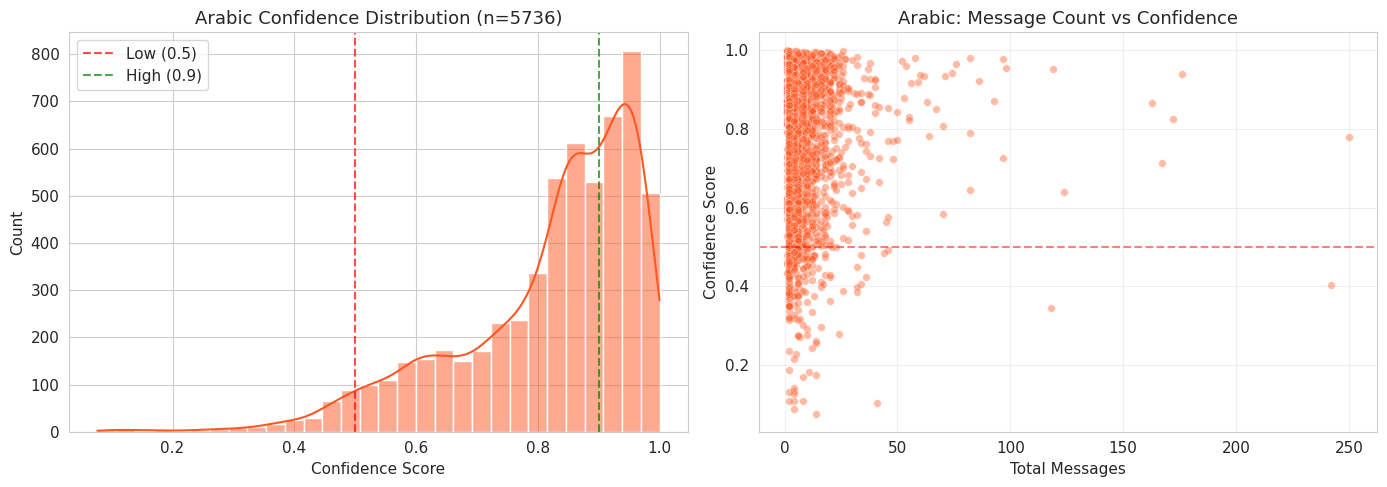

In [20]:
# ---------------------- TOPIC 9 - CELL 3: Arabic Confidence Deep Dive --------

arabic_df = df[df['conversation_language'].isin(['Arabic', 'Najdi Arabic'])].copy()
arabic_total = len(arabic_df)

if arabic_total > 0:
    arabic_low = arabic_df[arabic_df['language_confidence_score'] < 0.5]
    arabic_medium = arabic_df[(arabic_df['language_confidence_score'] >= 0.5) &
                              (arabic_df['language_confidence_score'] < 0.9)]
    arabic_high = arabic_df[arabic_df['language_confidence_score'] >= 0.9]

    print("\n")
    print("🔍 TOPIC 9B: ARABIC LANGUAGE CONFIDENCE DEEP DIVE")
    print("=" * 60)
    print(f"  Total Arabic + Najdi Arabic conversations: {arabic_total}")
    print(f"  Share of all data: {arabic_total/total_convs:.1%}")
    print(f"\n  📍 Confidence Breakdown:")
    print(f"     🟢 High (>= 0.9):   {len(arabic_high)} ({len(arabic_high)/arabic_total:.1%})")
    print(f"     🟡 Medium (0.5-0.9): {len(arabic_medium)} ({len(arabic_medium)/arabic_total:.1%})")
    print(f"     🔴 Low (< 0.5):     {len(arabic_low)} ({len(arabic_low)/arabic_total:.1%})")
    print(f"\n  📍 Arabic share of ALL low-confidence cases: {len(arabic_low)}/{low_conf} ({len(arabic_low)/max(low_conf,1):.1%})")

    print(f"\n  📍 Confidence vs Message Count (Arabic):")
    short_arabic = arabic_df[arabic_df['total_messages'] <= 2]
    long_arabic = arabic_df[arabic_df['total_messages'] > 2]
    print(f"     Short conversations (<=2 msgs): avg confidence = {short_arabic['language_confidence_score'].mean():.4f} (n={len(short_arabic)})")
    print(f"     Long conversations  (>2 msgs):  avg confidence = {long_arabic['language_confidence_score'].mean():.4f} (n={len(long_arabic)})")

    print(f"\n  📍 Likely Cause: Mixed-language conversations (Arabic-English code-switching)")
    print(f"     are common and reduce language detection confidence. Short conversations")
    print(f"     also have less text for the model to analyze, lowering scores.")
    print("=" * 60)

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Arabic confidence distribution
    sns.histplot(arabic_df['language_confidence_score'], bins=30, kde=True,
                 color='#FF5722', ax=axes[0])
    axes[0].set_title(f'Arabic Confidence Distribution (n={arabic_total})', fontsize=13)
    axes[0].set_xlabel('Confidence Score')
    axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='Low (0.5)')
    axes[0].axvline(0.9, color='green', linestyle='--', alpha=0.7, label='High (0.9)')
    axes[0].legend()

    # Right: Confidence by message count for Arabic
    sns.scatterplot(x='total_messages', y='language_confidence_score', data=arabic_df,
                    s=30, alpha=0.4, color='#FF5722', ax=axes[1])
    axes[1].set_title('Arabic: Message Count vs Confidence', fontsize=13)
    axes[1].set_xlabel('Total Messages')
    axes[1].set_ylabel('Confidence Score')
    axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('topic9_arabic_deep_dive.png', dpi=150, bbox_inches='tight')
    plt.show()

### 📝 Topic 9 — Key Takeaways

- **66.5% high confidence**, 30.9% medium, **2.7% low confidence** (332 conversations where the detected language may be wrong).
- **Arabic is the biggest problem**: Despite being 45.5% of all data, only 36.9% of Arabic conversations have high confidence (vs 66.5% overall). Arabic accounts for **71.7% of all low-confidence cases**.
- **Likely cause: Code-switching** — Arabic users frequently mix Arabic and English in the same conversation, confusing the language detection algorithm.
- **Very low confidence languages** (under 0.5 average): Dagbani (0.15), Nigerian Pidgin (0.16), Shona (0.03), Northern Sotho (0.04) — these are likely misclassified entirely.
- **Impact**: This means some conversations labeled "Arabic" may actually be mixed-language, and some labeled "English" may be Arabic-dominant. All language-based analyses should be interpreted with this caveat.

---

# 🤖 Topic 10: AI Performance Dashboard

**Goal**: Combine response time with language and time-of-day to create a comprehensive performance view. This section also introduces the **SLA (Service Level Agreement) table** — showing what percentage of conversations meet specific speed thresholds for each language.

**Columns used**: `avg_response_time_ai_sec`, `conversation_language`, `start_hour`, `total_messages`

**All data in this section uses the cleaned dataset** (top 1% outliers removed, cap at 83.52 seconds).

This topic has 2 cells:

| Cell | What It Does |
|------|-------------|
| 10.1 | Performance report — speed by language (top 15), speed by hour, speed vs conversation length, SLA table (text) |
| 10.2 | 4 charts — speed by language bar, speed by hour line, speed vs message count scatter, SLA stacked bar (top 5 languages) |

In [21]:

# =============================================================================
# TOPIC 10: AI PERFORMANCE DASHBOARD (NEW) — WITH OUTLIER HANDLING & SLA
# =============================================================================

# ---------------------- TOPIC 10 - CELL 1: Performance Report ----------------

df_ai = df.dropna(subset=['avg_response_time_ai_sec']).copy()

# Calculate 99th percentile for outlier cap
ai_p99 = df_ai['avg_response_time_ai_sec'].quantile(0.99)
df_ai_clean = df_ai[df_ai['avg_response_time_ai_sec'] <= ai_p99].copy()

print("\n")
print("🤖 TOPIC 10: AI PERFORMANCE DASHBOARD")
print("=" * 60)
print(f"  Conversations with AI response data: {len(df_ai)} out of {total_convs}")
print(f"  99th percentile cap: {ai_p99:.2f}s ({len(df_ai) - len(df_ai_clean)} outliers excluded)")

# A. AI Speed by Language (CLEANED, top 15 by volume)
print("\n  📍 AI Response Time by Language (Cleaned, Top 15 by volume):")
top15_ai_langs = df_ai_clean['conversation_language'].value_counts().head(15).index
df_ai_top15 = df_ai_clean[df_ai_clean['conversation_language'].isin(top15_ai_langs)]

ai_by_lang = df_ai_top15.groupby('conversation_language')['avg_response_time_ai_sec'].agg(
    ['mean', 'median', 'max', 'count']
).sort_values('mean', ascending=True)

print(f"  {'Language':<30} | {'Mean(s)':<10} | {'Median(s)':<10} | {'Max(s)':<10} | {'Count':<6}")
print("  " + "-" * 72)
for lang, row in ai_by_lang.iterrows():
    print(f"  {lang:<30} | {row['mean']:<10.2f} | {row['median']:<10.2f} | {row['max']:<10.2f} | {int(row['count']):<6}")

# B. AI Speed by Hour (CLEANED)
print("\n  📍 AI Response Time by Hour of Day (Cleaned):")
ai_by_hour = df_ai_clean.groupby('hour')['avg_response_time_ai_sec'].agg(['mean', 'count']).sort_index()
for hour, row in ai_by_hour.iterrows():
    speed_bar = "█" * min(int(row['mean'] * 2), 30)
    print(f"    {hour:02d}:00 → {row['mean']:.2f}s (n={int(row['count'])}) {speed_bar}")

# C. Speed vs Conversation Length (CLEANED)
print("\n  📍 AI Speed vs Conversation Length (Cleaned):")
median_msgs = df_ai_clean['total_messages'].median()
short_convs = df_ai_clean[df_ai_clean['total_messages'] <= median_msgs]
long_convs = df_ai_clean[df_ai_clean['total_messages'] > median_msgs]
print(f"    Short conversations (<={median_msgs:.0f} msgs): avg AI response = {short_convs['avg_response_time_ai_sec'].mean():.2f}s")
print(f"    Long conversations  (>{median_msgs:.0f} msgs):  avg AI response = {long_convs['avg_response_time_ai_sec'].mean():.2f}s")

# D. SLA Percentile Table
print("\n  📍 AI SPEED SLA TABLE (% of conversations meeting threshold):")
print("  " + "-" * 80)
print(f"  {'Language':<30} | {'<=1s':<8} | {'<=5s':<8} | {'<=15s':<8} | {'<=30s':<8} | {'Total':<6}")
print("  " + "-" * 80)

sla_thresholds = [1, 5, 15, 30]
sla_langs = df_ai['conversation_language'].value_counts().head(10).index

for lang in sla_langs:
    lang_data = df_ai[df_ai['conversation_language'] == lang]['avg_response_time_ai_sec']
    lang_total = len(lang_data)
    pcts = []
    for t in sla_thresholds:
        pct = (lang_data <= t).sum() / lang_total * 100
        pcts.append(f"{pct:.0f}%")
    print(f"  {lang:<30} | {pcts[0]:<8} | {pcts[1]:<8} | {pcts[2]:<8} | {pcts[3]:<8} | {lang_total:<6}")

print("  " + "-" * 80)

# Overall SLA
overall_data = df_ai['avg_response_time_ai_sec']
overall_pcts = []
for t in sla_thresholds:
    pct = (overall_data <= t).sum() / len(overall_data) * 100
    overall_pcts.append(f"{pct:.0f}%")
print(f"  {'OVERALL':<30} | {overall_pcts[0]:<8} | {overall_pcts[1]:<8} | {overall_pcts[2]:<8} | {overall_pcts[3]:<8} | {len(overall_data):<6}")
print("=" * 60)





🤖 TOPIC 10: AI PERFORMANCE DASHBOARD
  Conversations with AI response data: 12230 out of 12448
  99th percentile cap: 83.52s (123 outliers excluded)

  📍 AI Response Time by Language (Cleaned, Top 15 by volume):
  Language                       | Mean(s)    | Median(s)  | Max(s)     | Count 
  ------------------------------------------------------------------------
  Japanese                       | 0.58       | 0.25       | 32.50      | 347   
  Swahili                        | 0.70       | 0.33       | 39.50      | 573   
  Chinese                        | 1.07       | 0.33       | 8.00       | 55    
  Korean                         | 1.22       | 0.00       | 64.00      | 116   
  Urdu                           | 1.31       | 0.40       | 53.50      | 81    
  Spanish                        | 2.56       | 0.33       | 46.50      | 109   
  German                         | 2.70       | 0.00       | 39.89      | 50    
  French                         | 3.43       | 0.16       | 71

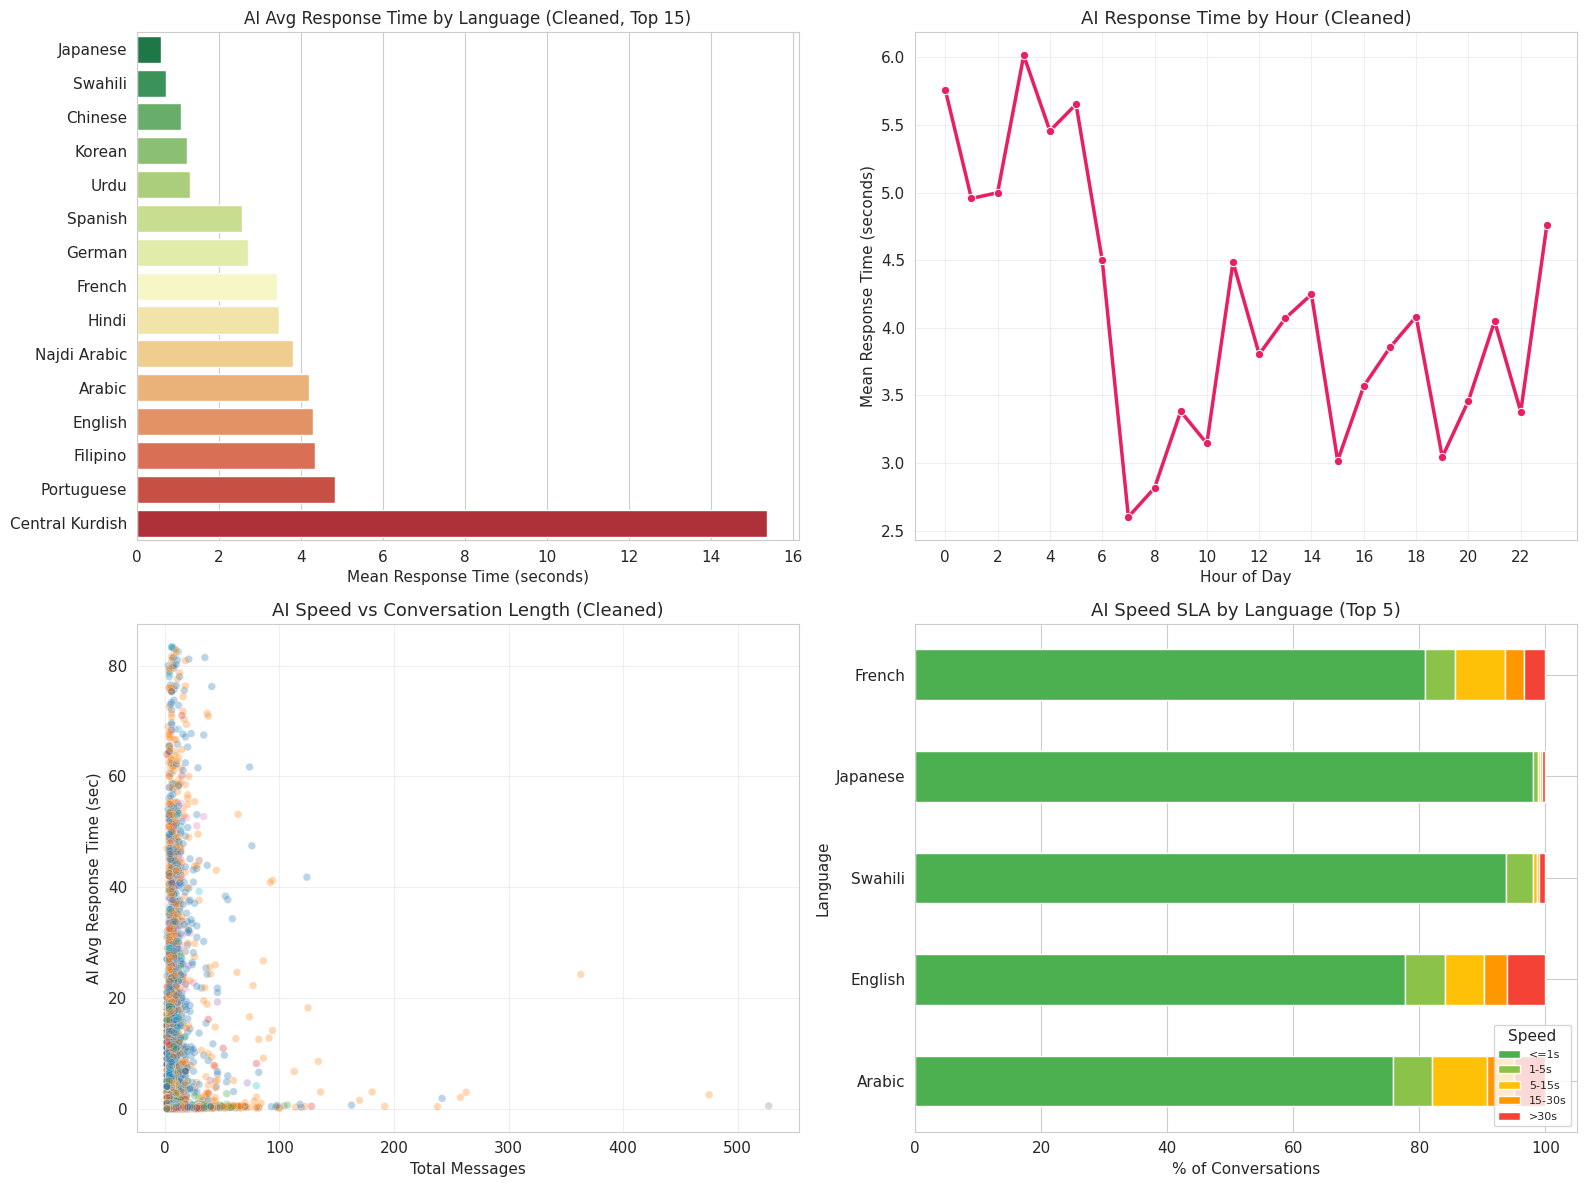

In [22]:
# ---------------------- TOPIC 10 - CELL 2: Visualizations (Cleaned) ----------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A. AI Speed by Language (Bar, cleaned, top 15)
if len(ai_by_lang) > 0:
    sns.barplot(x=ai_by_lang['mean'].values, y=ai_by_lang.index,
                palette='RdYlGn_r', ax=axes[0, 0])
    axes[0, 0].set_title(f'AI Avg Response Time by Language (Cleaned, Top 15)', fontsize=12)
    axes[0, 0].set_xlabel('Mean Response Time (seconds)')
    axes[0, 0].set_ylabel('')

# B. AI Speed by Hour (Line, cleaned)
if len(ai_by_hour) > 0:
    sns.lineplot(x=ai_by_hour.index, y=ai_by_hour['mean'], marker='o',
                 color='#E91E63', linewidth=2.5, ax=axes[0, 1])
    axes[0, 1].set_title('AI Response Time by Hour (Cleaned)', fontsize=13)
    axes[0, 1].set_xlabel('Hour of Day')
    axes[0, 1].set_ylabel('Mean Response Time (seconds)')
    axes[0, 1].set_xticks(range(0, 24, 2))
    axes[0, 1].grid(True, alpha=0.3)

# C. AI Speed vs Total Messages (Scatter, cleaned)
if len(df_ai_clean) > 0:
    sns.scatterplot(x='total_messages', y='avg_response_time_ai_sec', data=df_ai_clean,
                    hue='conversation_language', s=30, alpha=0.3, ax=axes[1, 0],
                    palette='tab10', legend=False)
    axes[1, 0].set_title('AI Speed vs Conversation Length (Cleaned)', fontsize=13)
    axes[1, 0].set_xlabel('Total Messages')
    axes[1, 0].set_ylabel('AI Avg Response Time (sec)')
    axes[1, 0].grid(True, alpha=0.3)

# D. SLA Visual — stacked bar for top 5 languages
sla_visual_langs = list(sla_langs[:5])
sla_rows = []
for lang in sla_visual_langs:
    lang_data = df_ai[df_ai['conversation_language'] == lang]['avg_response_time_ai_sec']
    n = len(lang_data)
    pct_1 = (lang_data <= 1).sum() / n * 100
    pct_5 = ((lang_data > 1) & (lang_data <= 5)).sum() / n * 100
    pct_15 = ((lang_data > 5) & (lang_data <= 15)).sum() / n * 100
    pct_30 = ((lang_data > 15) & (lang_data <= 30)).sum() / n * 100
    pct_over = (lang_data > 30).sum() / n * 100
    sla_rows.append({'Language': lang, '<=1s': pct_1, '1-5s': pct_5,
                     '5-15s': pct_15, '15-30s': pct_30, '>30s': pct_over})

sla_df = pd.DataFrame(sla_rows).set_index('Language')
sla_df.plot(kind='barh', stacked=True, ax=axes[1, 1],
            color=['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336'])
axes[1, 1].set_title('AI Speed SLA by Language (Top 5)', fontsize=13)
axes[1, 1].set_xlabel('% of Conversations')
axes[1, 1].legend(title='Speed', fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('topic10_ai_performance.png', dpi=150, bbox_inches='tight')
plt.show()


### 📝 Topic 10 — Key Takeaways

- **Fastest languages**: Japanese (0.58s mean) and Swahili (0.70s mean).
- **Slowest language**: Central Kurdish — **15.37s mean, 11.12s median**. This is 30× slower than Arabic or English. Only **36% of Central Kurdish conversations meet the 1-second SLA**, compared to 78% overall.
- **SLA performance**: Overall, 78% of conversations get a response within 1 second, 84% within 5 seconds, 91% within 15 seconds, and 95% within 30 seconds.
- **Speed by hour**: Fastest during morning (7–8 AM, ~2.7s), slowest during late night (midnight–5 AM, ~5.5s).
- **Speed by conversation length**: Short conversations (≤4 messages) average 2.03s response. Long conversations (5+ messages) average 6.99s — a 3.4× increase, suggesting the bot takes longer to process context in extended conversations.
- **🔴 Action required**: Central Kurdish performance is a critical issue that should be escalated to the development team.

---

---

# ✅ Summary & Recommendations

## Key Findings

| Finding | Impact | Priority |
|---------|--------|----------|
| Central Kurdish response time is 30× slower than other languages | 164 conversations affected, only 36% under 1 second | 🔴 Critical |
| 71.7% of low-confidence language detections are Arabic | Affects accuracy of all language-based analyses | 🔴 High |
| 55% of bot failures concentrated in January–February | 60 failures in 2 months suggest system issue | 🟠 High |
| 30 conversations where users asked real questions and got no reply | Direct user impact — lost trust | 🟠 High |
| French emerged as 3rd largest language in 2026 | Growing francophone African user base | 🟡 Monitor |
| Multi-session users send 8× more messages | 357 power users with complex needs | 🟡 Opportunity |

## Recommended Actions

1. **Investigate Central Kurdish processing** — check tokenization, model routing, and infrastructure for this language
2. **Improve Arabic language detection** — train on mixed Arabic-English conversations, or add a "Mixed Language" category
3. **Check server logs for January–February** — identify what caused the failure spike
4. **Review the 30 critical bot failures individually** — understand why each one happened and prevent recurrence
5. **Ensure French language quality** — the growing francophone user base needs proper support
6. **Analyze multi-session conversation content** — these 357 conversations reveal your most complex use cases and potential content gaps